# B41 Bus Route — Quantile Regression Post-Processing on LSTM Predictions

## Overview

This notebook implements a **Quantile Regression (QR) post-processing layer** on top of a
pre-trained Long Short-Term Memory (LSTM) neural network for bus delay prediction on the
B41 route (Brooklyn, NYC).

### Motivation
Transit delay prediction is inherently uncertain. A point forecast (e.g. "the next bus
arrives in 8 minutes") tells passengers nothing about how reliable that estimate is.
By wrapping the LSTM with Quantile Regression, we produce **prediction intervals** —
e.g. "80% of the time, the delay falls between 3 and 17 minutes" — which are far more
actionable for operational planning.

### Key Design Principle
We do **not** retrain the LSTM. Instead, we treat it as a fixed black box and apply QR
as a lightweight calibration layer on its residuals. This approach is:
- **Non-invasive:** LSTM weights remain frozen.
- **Computationally cheap:** QR training runs in seconds.
- **Theoretically grounded:** Pinball loss optimisation and conformal coverage guarantees
  apply without distributional assumptions.

### Data Splits

| Split    | Months          | Role                               |
|----------|-----------------|------------------------------------|
| train    | June–Early October    | Fit QR models on LSTM residuals    |
| val      | Late October-Early December        | Tune/validate prediction intervals |
| test     | Mid-late December        | Final held-out evaluation          |

### 15 LSTM Input Features

| Category     | Features                                                                                 |
|--------------|------------------------------------------------------------------------------------------|
| Event Presence| FLATBUSH AV/PROSPECT PARK ENT, LIVINGSTON ST/NEVINS ST, FLATBUSH AV/BERGEN ST,          |
|              | CADMAN PLZ W/MONTAGUE ST, FLATBUSH AV/PLAZA ST E                                        |
| Weather      | temperatu_rec, precipitation, wind_speed_kmh                                                |
| Temporal     | month, weekday, hour, isweekend, isholiday                                               |
| Lag features | dayly_lag, weekly_lag                                                                      |

### Evaluation Metrics
- **Point accuracy:** MAE, RMSE, R²
- **Interval quality:** Coverage (80%), interval width, Pinball loss (Q10, Q50, Q90)
- **Operational:** Disruption detection F1 (threshold: 10 min)

## 1 · Imports & Global Settings

All third-party dependencies are imported here. The `matplotlib` defaults are set once
globally so every subsequent plot inherits a consistent, publication-ready style
(no top/right spines, 130 DPI).

> **Reproducibility note:** No random seed is required because `QuantileRegressor` (via the
> `highs` LP solver) is deterministic.

In [97]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm

from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Libraries loaded.")

Libraries loaded.


## 2 · Configuration

All file paths and modelling hyperparameters live here. Update the three CSV paths to
point to your local LSTM output files before running the notebook.

| Constant         | Value                           | Purpose                              |
|------------------|---------------------------------|--------------------------------------|
| `CSV_TRAIN`      | `lstm_train_predictions.csv`    | June–Late October LSTM outputs            |
| `CSV_VAL`        | `lstm_val_predictions.csv`      | Late October-Early December LSTM outputs                  |
| `CSV_TEST`       | `lstm_test_predictions.csv`     | Mid-Late December LSTM outputs                |
| `PATH_FEATURES`  | `final_dataset_corrected.csv`   | Full 15-feature matrix               |
| `QR_QUANTILES`   | (0.1, 0.5, 0.9)                 | Lower bound, median, upper bound     |
| `DISRUPTION_THR` | 10 minutes                      | Operational disruption threshold     |

`QR_FEATURE_COLS` = 15 LSTM features **+** `ypred` (16 total). The LSTM point prediction
is included as a covariate because residual variance tends to scale with prediction
magnitude (heteroscedasticity).

In [98]:
# ── Prediction CSV paths (one per split) ─────────────────────────────────────
CSV_TRAIN     = 'lstm_train_predictions.csv'   # June + October
CSV_VAL       = 'lstm_val_predictions.csv'     # August
CSV_TEST      = 'lstm_test_predictions.csv'    # December

# ── Full LSTM feature matrix ─────────────────────────────────────────────────
PATH_FEATURES = 'final_dataset_corrected.csv'

# ── 15 LSTM feature column names (as they appear in final_dataset_corrected.csv) ──
LSTM_FEATURE_COLS = [
 'FLATBUSH AV/PROSPECT PARK ENT',
 'LIVINGSTON ST/NEVINS ST',
 'FLATBUSH AV/BERGEN ST',
 'CADMAN PLZ W/MONTAGUE ST',
 'FLATBUSH AV/PLAZA ST E',
 'temperature_c',
 'precipitation',
 'windspeed_kmh',
 'month',
 'week_day',
 'hour',
 'is_weekend',
 'is_holiday',
 'dayly_lag',
 'weekly_lag',
]

# ── QR covariate set: all LSTM features + LSTM point prediction ─────────────
# ypred is kept because residual variance often scales with prediction magnitude
QR_FEATURE_COLS = LSTM_FEATURE_COLS + ['ypred']   # 10 + 1 = 11 covariates

# ── Model & evaluation settings ───────────────────────────────────────────────
QR_QUANTILES   = [0.1, 0.5, 0.9]
DISRUPTION_THR = 10

print('Configuration set.')
print(f'  LSTM features  : {len(LSTM_FEATURE_COLS)}')
print(f'  QR covariates   : {len(QR_FEATURE_COLS)} (LSTM features + ypred)')
print(f'  QR quantiles    : {QR_QUANTILES}')
print(f'  Disruption τ    : {DISRUPTION_THR} min')

Configuration set.
  LSTM features  : 15
  QR covariates   : 16 (LSTM features + ypred)
  QR quantiles    : [0.1, 0.5, 0.9]
  Disruption τ    : 10 min


## 3 · Load Pre-computed LSTM Outputs

Three CSV files are loaded — one per data split — and concatenated into a single
`pred_df`. The feature matrix (`feat_df`) is loaded separately and merged on `timestamp`.

**Column schema after merge:**

| Column       | Description                          |
|--------------|--------------------------------------|
| `timestamp`  | 30-minute interval (datetime64)      |
| `ypred`      | LSTM point prediction (minutes)      |
| `ytrue`      | Observed delay (minutes)             |
| `residuals`  | `ytrue − ypred` (LSTM error)         |
| `split`      | train / val / test                   |
| 15 features  | See Section 2 configuration table    |

No missing values were found after the timestamp merge (all 4,282 prediction rows matched).

In [99]:
# ── 3a  Load prediction CSVs ──────────────────────────────────────────────────
pred_df = pd.concat([
    pd.read_csv(CSV_TRAIN),
    pd.read_csv(CSV_VAL),
    pd.read_csv(CSV_TEST),
], ignore_index=True)
pred_df['timestamp'] = pd.to_datetime(pred_df['timestamp'])

train_df = pd.read_csv("lstm_train_predictions.csv", parse_dates=["timestamp"])
train_df["split"] = "train"

val_df = pd.read_csv("lstm_val_predictions.csv", parse_dates=["timestamp"])
val_df["split"] = "val"

test_df = pd.read_csv("lstm_test_predictions.csv", parse_dates=["timestamp"])
test_df["split"] = "test"

pred_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print('Prediction rows per split:')
print(pred_df.groupby('split').size().to_string())
print(f'Total prediction rows : {len(pred_df):,}')

Prediction rows per split:
split
test      640
train    3032
val       610
Total prediction rows : 4,282


In [100]:
pred_df.columns

Index(['Unnamed: 0', 'timestamp', 'ypred', 'ytrue', 'residuals', 'split'], dtype='object')

In [101]:
pred_df.head()

,Unnamed: 0,timestamp,ypred,ytrue,residuals,split
0,0,2017-06-08 14:30:00,8.216854,14.734661,6.517807,train
1,1,2017-06-08 15:00:00,8.739904,17.297508,8.557604,train
2,2,2017-06-08 15:30:00,8.983679,13.815071,4.831392,train
3,3,2017-06-08 16:00:00,9.271424,14.993851,5.722426,train
4,4,2017-06-08 16:30:00,9.480982,16.984011,7.503029,train


In [102]:
# ── 3b Load feature dataframe ────────────────────────────────────────────────
feat_df = pd.read_csv(PATH_FEATURES, delimiter=";", parse_dates=["timestamp"])

#LSTM_FEATURE_COLS = [
 #   "temperature_c",
  #  "precipitation",
   # "windspeed_kmh",
    #"month",
    #"week_day",
   # "hour",
   # "is_weekend",
   # "is_holiday",
   # "dayly_lag",
   # "weekly_lag",
#]

feat_df = feat_df[["timestamp"] + LSTM_FEATURE_COLS].dropna().copy()

print(f"\nFeature matrix rows: {len(feat_df):,}")


# ── 3c Merge on timestamp only ──────────────────────────────────────────────
full_df = pred_df.merge(feat_df, on="timestamp", how="left")

n_missing = full_df[LSTM_FEATURE_COLS].isna().any(axis=1).sum()
if n_missing > 0:
    print(f"\n⚠ {n_missing} rows could not be matched — they will be dropped.")
    full_df.dropna(subset=LSTM_FEATURE_COLS, inplace=True)
else:
    print("\n✓ All prediction rows matched to feature rows — no missing values.")

print(f"\nfull_df shape : {full_df.shape}")
print("\nSample rows:")
display(full_df.head(3))


Feature matrix rows: 4,456

✓ All prediction rows matched to feature rows — no missing values.

full_df shape : (4282, 21)

Sample rows:


,Unnamed: 0,timestamp,ypred,ytrue,residuals,split,FLATBUSH AV/PROSPECT PARK ENT,LIVINGSTON ST/NEVINS ST,FLATBUSH AV/BERGEN ST,CADMAN PLZ W/MONTAGUE ST,...,temperature_c,precipitation,windspeed_kmh,month,week_day,hour,is_weekend,is_holiday,dayly_lag,weekly_lag
0,0,2017-06-08 14:30:00,8.216854,14.734661,6.517807,train,1,0,0,0,...,17.45,0.0,16.60,-0.5,-0.016601,-0.933013,0,1,4.340541,9.655128
1,1,2017-06-08 15:00:00,8.739904,17.297508,8.557604,train,1,0,0,0,...,17.00,0.0,17.00,-0.5,-0.016601,-1.060660,0,1,5.747807,7.143868
2,2,2017-06-08 15:30:00,8.983679,13.815071,4.831392,train,0,0,0,0,...,16.50,0.0,16.75,-0.5,-0.016601,-1.060660,0,1,11.380637,9.652485


Spearman ρ with |residual| — training set
------------------------------------------------
  windspeed_kmh             +0.200  ██████
  month                     +0.197  █████
  is_holiday                -0.188  █████
  dayly_lag                 +0.133  ████
  weekly_lag                +0.126  ███
  LIVINGSTON ST/NEVINS ST   -0.110  ███
  hour                      -0.084  ██
  CADMAN PLZ W/MONTAGUE ST  +0.072  ██
  FLATBUSH AV/BERGEN ST     -0.059  █
  temperature_c             -0.057  █
  is_weekend                -0.052  █
  FLATBUSH AV/PLAZA ST E    +0.050  █
  FLATBUSH AV/PROSPECT PARK ENT -0.043  █
  precipitation             +0.031  
  week_day                  -0.003  


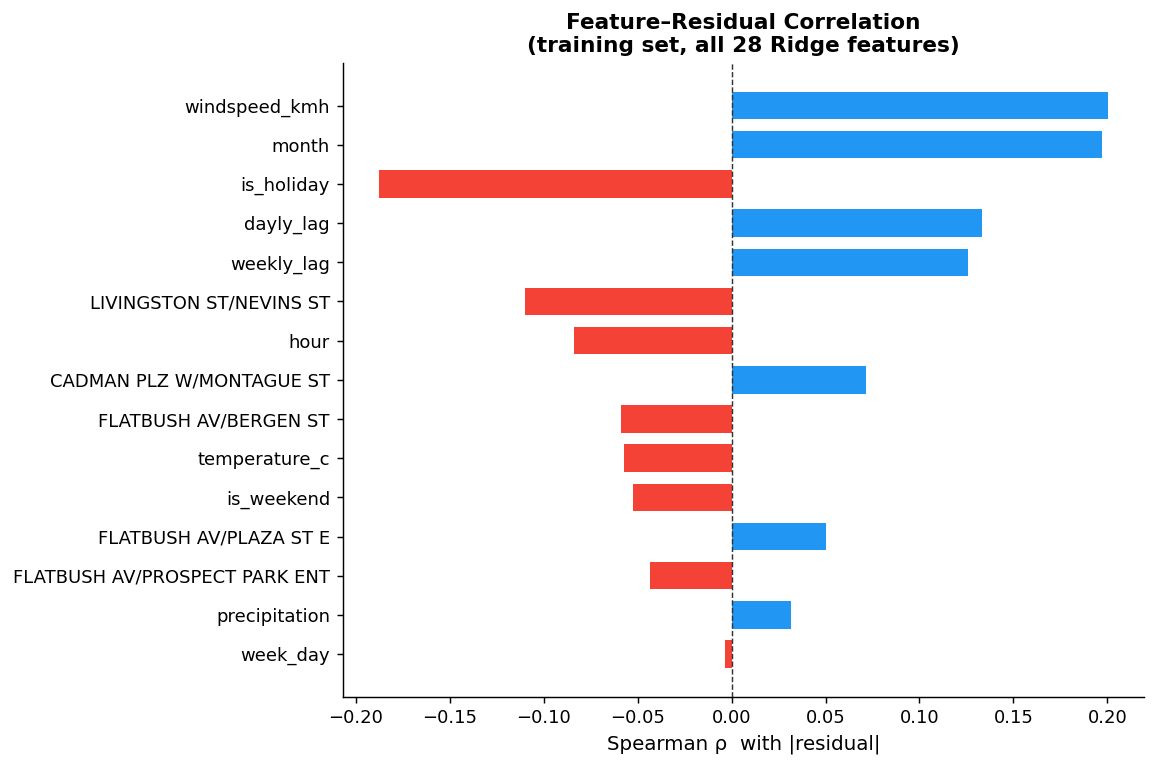

In [103]:
# ── Spearman correlation: each feature vs |residual| on training set ──────────
train_tmp = full_df[full_df['split'] == 'train'].copy()
train_tmp['abs_residual'] = train_tmp['residuals'].abs()

corr = (train_tmp[LSTM_FEATURE_COLS + ['abs_residual']]
        .corr(method='spearman')['abs_residual']
        .drop('abs_residual')
        .sort_values(key=abs, ascending=False))

print('Spearman ρ with |residual| — training set')
print('-' * 48)
for feat, val in corr.items():
    bar  = '█' * int(abs(val) * 30)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:<25} {sign}{abs(val):.3f}  {bar}')

# Bar chart
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2196F3' if v >= 0 else '#F44336' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1],
        color=colors[::-1], edgecolor='none', height=0.7)
ax.axvline(0, color='#333', linewidth=0.8, linestyle='--')
ax.set_xlabel('Spearman ρ  with |residual|', fontsize=11)
ax.set_title('Feature–Residual Correlation\n(training set, all 28 Ridge features)',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [158]:
# Spearman rank correlation: non-parametric, robust to outliers and monotone
# non-linearities. Features are ranked by absolute correlation magnitude.
# Top predictors of LSTM residuals: wind speed, month, holiday flag, and lag features.
# This motivates including ypred and temporal features in the enhanced QR (Section 12).

## 4  Exploratory Analysis of LSTM Residuals

Before fitting the QR layer we inspect the distribution of residuals across splits and horizons.  
Non-zero mean or growing spread with horizon both signal opportunities for quantile correction.

In [104]:
# ── Residual summary per split ─────────────────────────────────────────────────
print('Residual statistics per split')

summary = pd.DataFrame({
    'train': train_df['residuals'],
    'val': val_df['residuals'],
    'test': test_df['residuals'],
}).agg(['mean', 'std', 'min', 'max',
        lambda s: s.quantile(0.10),
        lambda s: s.quantile(0.90)]).rename(index={'<lambda_0>': 'q10', '<lambda_1>': 'q90'}).round(3)

print(summary.to_string())
print()


# ── Disruption rate per split ──────────────────────────────────────────────────
print('Disruption rate per split (ytrue > threshold):')

for name, df_ in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    rate = (df_['ytrue'] > DISRUPTION_THR).mean()
    print(f'  {name}: {rate:.1%}')

Residual statistics per split
            train      val    test
mean        0.044   -0.284  -1.621
std         7.567    9.731   6.963
min       -15.721  -10.844 -11.696
max       143.815  157.675  74.866
<lambda>   -4.684   -5.831  -6.490
<lambda>    4.702    5.148   3.839

Disruption rate per split (ytrue > threshold):
  Train: 26.7%
  Val: 26.2%
  Test: 22.0%


In [105]:
res_by_split = (
    full_df.groupby('split')['residuals']
    .agg(mean='mean', std='std')
    .round(3)
)

print('Residual mean and std by split:')
print(res_by_split.to_string())

Residual mean and std by split:
        mean    std
split              
test  -1.621  6.963
train  0.044  7.567
val   -0.284  9.731


## 5  Load Features for the QR Layer

In [106]:
# All LSTM features are now loaded directly from final_dataset_corrected.csv
# and merged into full_df — no manual feature engineering needed.

print('QR feature columns available in full_df:')
for col in QR_FEATURE_COLS:
    present = col in full_df.columns
    print(f'  {"✓" if present else "✗"}  {col}')

missing_cols = [c for c in QR_FEATURE_COLS if c not in full_df.columns]
if missing_cols:
    print(f'\n⚠  Missing columns: {missing_cols}')
else:
    print(f'\n✓  All {len(QR_FEATURE_COLS)} QR covariates confirmed in full_df.')

QR feature columns available in full_df:
  ✓  FLATBUSH AV/PROSPECT PARK ENT
  ✓  LIVINGSTON ST/NEVINS ST
  ✓  FLATBUSH AV/BERGEN ST
  ✓  CADMAN PLZ W/MONTAGUE ST
  ✓  FLATBUSH AV/PLAZA ST E
  ✓  temperature_c
  ✓  precipitation
  ✓  windspeed_kmh
  ✓  month
  ✓  week_day
  ✓  hour
  ✓  is_weekend
  ✓  is_holiday
  ✓  dayly_lag
  ✓  weekly_lag
  ✓  ypred

✓  All 16 QR covariates confirmed in full_df.


## 6  Helper Functions

In [107]:
def pinball_loss(y_true, y_pred, q):
    """Pinball (quantile) loss for a single quantile q ∈ (0, 1)."""
    e = np.asarray(y_true) - np.asarray(y_pred)
    return float(np.mean(np.maximum(q * e, (q - 1) * e)))

def interval_coverage(y_true, lo, hi):
    """Fraction of observations that fall inside [lo, hi]."""
    return float(np.mean((np.asarray(y_true) >= lo) & (np.asarray(y_true) <= hi)))

def interval_width(lo, hi):
    """Mean width of the prediction interval."""
    return float(np.mean(np.asarray(hi) - np.asarray(lo)))

def evaluate_point_forecast(y_true, y_pred):
    """Return (MAE, RMSE, R²) for a point forecast."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, r2

def evaluate_disruption(y_true, y_pred, thr=DISRUPTION_THR):
    """Precision, recall, and F1 for binary disruption detection."""
    d_true = (np.asarray(y_true) > thr).astype(int)
    d_pred = (np.asarray(y_pred) > thr).astype(int)
    prec = float(d_true[d_pred == 1].mean()) if d_pred.sum() > 0 else 0.0
    rec  = float(d_pred[d_true == 1].mean()) if d_true.sum() > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return prec, rec, f1

print("Helper functions defined.")

Helper functions defined.


## 7  Quantile Regression — Fitting

Three separate `QuantileRegressor` models are trained — one per quantile (τ = 0.1, 0.5, 0.9).

**Why three separate models?**
`sklearn`'s `QuantileRegressor` solves a Linear Programme (LP) for a fixed τ. Running three
independent LPs is computationally straightforward and allows each quantile to have a
different linear response surface.

**Target variable:** LSTM residuals (`ytrue − ypred`) on the *training* split.
**Covariates:** 15 LSTM input features **+** `ypred` (16 total), standardised via
`StandardScaler` (fitted on train, applied to val/test).

**Reconstruction formula:**

    ŷ_q(x) = ŷ_LSTM(x) + q̂(x)

where `q̂(x)` is the QR-predicted residual at quantile τ.

In [108]:
# train_df, val_df, test_df must already exist
# columns: timestamp, ytrue, ypred, residuals

feat_df = pd.read_csv(PATH_FEATURES, delimiter=";", parse_dates=["timestamp"])
feat_df = feat_df[["timestamp"] + LSTM_FEATURE_COLS].copy()

train_qr = train_df.merge(feat_df, on="timestamp", how="left")
val_qr   = val_df.merge(feat_df, on="timestamp", how="left")
test_qr  = test_df.merge(feat_df, on="timestamp", how="left")

for name, df_ in [("train", train_qr), ("val", val_qr), ("test", test_qr)]:
    missing = df_[LSTM_FEATURE_COLS].isna().any(axis=1).sum()
    if missing > 0:
        print(f"⚠ {name}: {missing} rows missing QR features — dropping them.")
        df_.dropna(subset=LSTM_FEATURE_COLS, inplace=True)

models = {}
val_preds = {}
test_preds = {}

X_tr = train_qr[QR_FEATURE_COLS].values
X_vl = val_qr[QR_FEATURE_COLS].values
X_ts = test_qr[QR_FEATURE_COLS].values
y_tr = train_qr["residuals"].values

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_vl_s = scaler.transform(X_vl)
X_ts_s = scaler.transform(X_ts)

for q in QR_QUANTILES:
    qr = QuantileRegressor(quantile=q, alpha=1e-4, solver="highs")
    qr.fit(X_tr_s, y_tr)
    models[q] = qr
    val_preds[q] = val_qr["ypred"].values + qr.predict(X_vl_s)
    test_preds[q] = test_qr["ypred"].values + qr.predict(X_ts_s)

# Validation metrics
y_vl = val_qr["ytrue"].values
mae_v, rmse_v, r2_v = evaluate_point_forecast(y_vl, val_preds[0.5])
cov_v = interval_coverage(y_vl, val_preds[0.1], val_preds[0.9])
wid_v = interval_width(val_preds[0.1], val_preds[0.9])
pb10_v = pinball_loss(y_vl, val_preds[0.1], 0.1)
pb90_v = pinball_loss(y_vl, val_preds[0.9], 0.9)
_, _, f1_v = evaluate_disruption(y_vl, val_preds[0.5], DISRUPTION_THR)

val_metrics_df = pd.DataFrame([{
    "MAE": mae_v,
    "RMSE": rmse_v,
    "R2": r2_v,
    "Coverage80": cov_v,
    "Width80": wid_v,
    "PB10": pb10_v,
    "PB90": pb90_v,
    "F1": f1_v,
}])

# Test metrics
y_ts = test_qr["ytrue"].values
mae_t, rmse_t, r2_t = evaluate_point_forecast(y_ts, test_preds[0.5])
cov_t = interval_coverage(y_ts, test_preds[0.1], test_preds[0.9])
wid_t = interval_width(test_preds[0.1], test_preds[0.9])
pb10_t = pinball_loss(y_ts, test_preds[0.1], 0.1)
pb90_t = pinball_loss(y_ts, test_preds[0.9], 0.9)
_, _, f1_t = evaluate_disruption(y_ts, test_preds[0.5], DISRUPTION_THR)

test_metrics_df = pd.DataFrame([{
    "MAE": mae_t,
    "RMSE": rmse_t,
    "R2": r2_t,
    "Coverage80": cov_t,
    "Width80": wid_t,
    "PB10": pb10_t,
    "PB90": pb90_t,
    "F1": f1_t,
}])

print("QR models trained for LSTM.")
print(f"  QR covariates used : {len(QR_FEATURE_COLS)}")
print(f"  Total models fitted: {len(QR_QUANTILES)}")

QR models trained for LSTM.
  QR covariates used : 16
  Total models fitted: 3


## 8 Validation and Test Summary

Median-forecast MAE on both splits for every horizon, followed by aggregate test-set metrics.

In [109]:
# ── Validation and Test Summary ──────────────────────────────────────────────
_val = val_metrics_df.copy()
_val["split"] = "val"

_test = test_metrics_df.copy()
_test["split"] = "test"

# Standardise column names
_rename = {
    "Coverage80": "coverage80",
    "Width80": "width80",
    "PB10": "pinball10",
    "PB90": "pinball90",
}
_val = _val.rename(columns=_rename)
_test = _test.rename(columns=_rename)

qr_results_df = pd.concat([_val, _test], ignore_index=True)

# pinball50 approximation from MAE if you still want the column
qr_results_df["pinball50"] = (qr_results_df["MAE"] / 2).round(3)

# Summary table by split
summary_metrics = qr_results_df.set_index("split")[[
    "MAE", "RMSE", "R2", "F1",
    "coverage80", "width80",
    "pinball10", "pinball50", "pinball90",
]].round(3)

print("QR Residual Model — Metrics by split")
print(summary_metrics.to_string())
print()

# Aggregate test metrics
avg_test = (
    qr_results_df[qr_results_df["split"] == "test"][[
        "MAE", "RMSE", "R2", "F1",
        "coverage80", "width80",
        "pinball10", "pinball50", "pinball90",
    ]]
    .mean()
    .round(3)
)

print("Test set metrics")
print(avg_test.to_string())

QR Residual Model — Metrics by split
         MAE   RMSE     R2     F1  coverage80  width80  pinball10  pinball50  pinball90
split                                                                                  
val    4.508  9.688  0.069  0.565       0.808   12.750      0.615      2.254      1.756
test   4.839  7.426  0.132  0.594       0.808   14.318      0.634      2.419      1.420

Test set metrics
MAE            4.839
RMSE           7.426
R2             0.132
F1             0.594
coverage80     0.808
width80       14.318
pinball10      0.634
pinball50      2.419
pinball90      1.420


## 9 Interval Diagnostics — Test Set

Per-horizon breakdown: MAE, 80 % coverage, 80 % width, and pinball losses at all three quantiles.

**Interpretation guide**
- `coverage80` should be close to **0.80** — below → over-confident; above → over-conservative.
- `width80` measures *sharpness* — smaller is better given adequate coverage.
- `pinball50` equals `MAE / 2` when the median is used as the point forecast.

In [111]:
# ── Test-set diagnostics ─────────────────────────────────────────────────────
test_sorted = qr_results_df[qr_results_df["split"] == "test"].copy()

diag = test_sorted[[
    "MAE", "coverage80", "width80",
    "pinball10", "pinball50", "pinball90"
]].copy()

diag.index = ["test"]

print("Test-set uncertainty diagnostics")
print(diag.to_string())

Test-set uncertainty diagnostics
           MAE  coverage80    width80  pinball10  pinball50  pinball90
test  4.838503    0.807813  14.317726   0.633636      2.419   1.419655


## 10 Save Row-Level Predictions

Export the full prediction DataFrame

In [112]:
# ── 10 Save Row-Level Predictions ───────────────────────────────────────────
qr_pred_rows = []

for splitname, splitdf, predsdict in [
    ("val", val_df, val_preds),
    ("test", test_df, test_preds),
]:
    lo = predsdict[0.1]
    med = predsdict[0.5]
    hi = predsdict[0.9]
    ytrue = splitdf["ytrue"].values

    qr_pred_rows.append(pd.DataFrame({
        "timestamp": splitdf["timestamp"].values,
        "split": splitname,
        "ytrue": ytrue,
        "ypred": splitdf["ypred"].values,
        "q10": lo,
        "q50": med,
        "q90": hi,
        "interval_width": hi - lo,
        "is_covered": ((ytrue >= lo) & (ytrue <= hi)).astype(int),
    }))

qr_pred_df = pd.concat(qr_pred_rows, ignore_index=True)

OUTPUT_CSV = "prediction_qr_residual.csv"
qr_pred_df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved {OUTPUT_CSV}  {len(qr_pred_df):,} rows  {qr_pred_df.shape[1]} columns")
print("\nColumns:", list(qr_pred_df.columns))

Saved prediction_qr_residual.csv  1,250 rows  9 columns

Columns: ['timestamp', 'split', 'ytrue', 'ypred', 'q10', 'q50', 'q90', 'interval_width', 'is_covered']


## 11  Visualisations

In [113]:
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

test_df = qr_pred_df[qr_pred_df["split"] == "test"].copy().sort_values("timestamp")
val_df  = qr_pred_df[qr_pred_df["split"] == "val"].copy().sort_values("timestamp")

### 11.1  Residual Distribution: Train vs Val vs Test

Shows how well the LSTM centred its errors

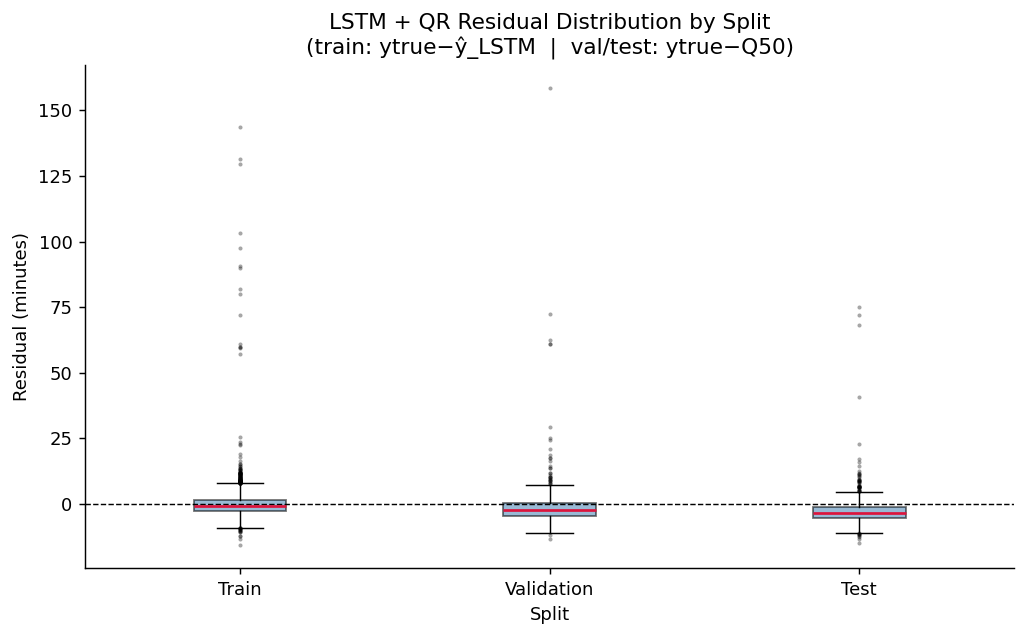

In [144]:
# ── Section 11.1 ── Residual Distribution: Train / Val / Test
# Pull splits from fulldf (contains all 3 splits) for plotting
traindf_plot = full_df[full_df['split'] == 'train'].copy()
valdf_plot   = qr_pred_df[qr_pred_df['split'] == 'val'].copy()   # qr_pred_df has val+test
testdf_plot  = qr_pred_df[qr_pred_df['split'] == 'test'].copy()

# Recompute residual from QR median for val/test; use raw residuals for train
traindf_plot['residual_plot'] = traindf_plot['residuals']               # ytrue - ypred (raw LSTM)
valdf_plot['residual_plot']   = valdf_plot['ytrue'] - valdf_plot['q50'] # ytrue - QR median
testdf_plot['residual_plot']  = testdf_plot['ytrue'] - testdf_plot['q50']

residuals = [
    traindf_plot['residual_plot'].dropna().values,
    valdf_plot['residual_plot'].dropna().values,
    testdf_plot['residual_plot'].dropna().values,
]
labels = ['Train', 'Validation', 'Test']

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    residuals,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='crimson', linewidth=1.5),
    boxprops=dict(facecolor='steelblue', alpha=0.55),
    flierprops=dict(marker='.', markersize=2.5, alpha=0.35),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Split')
ax.set_ylabel('Residual (minutes)')
ax.set_title('LSTM + QR Residual Distribution by Split\n(train: ytrue−ŷ_LSTM  |  val/test: ytrue−Q50)')
plt.tight_layout()
plt.show()

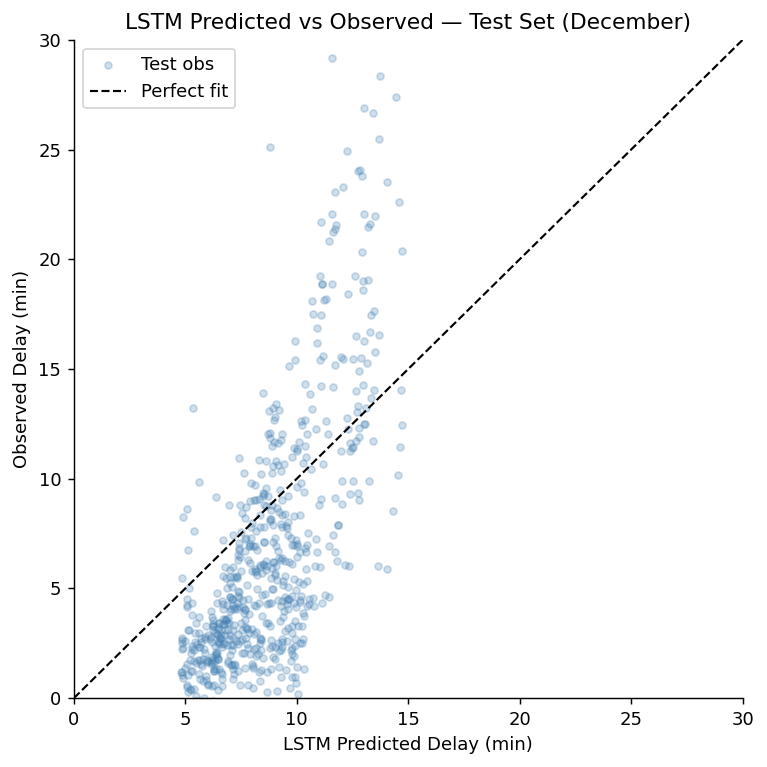

In [116]:
# ── 11.2  LSTM Point-Forecast Quality: Scatter ytrue vs ypred (test set) ──────
# Shows whether the base LSTM is biased or heteroscedastic
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(test_df["ypred"], test_df["ytrue"],
           alpha=0.25, s=15, color="steelblue", label="Test obs")
lim = max(test_df[["ypred", "ytrue"]].max())
lim = min(lim, 30)   # cap for readability
ax.plot([0, lim], [0, lim], "k--", linewidth=1.2, label="Perfect fit")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("LSTM Predicted Delay (min)")
ax.set_ylabel("Observed Delay (min)")
ax.set_title("LSTM Predicted vs Observed — Test Set (December)")
ax.legend()
plt.tight_layout()
plt.show()

### 11.3  Pinball Loss by Quantile vs Horizon — Test Set

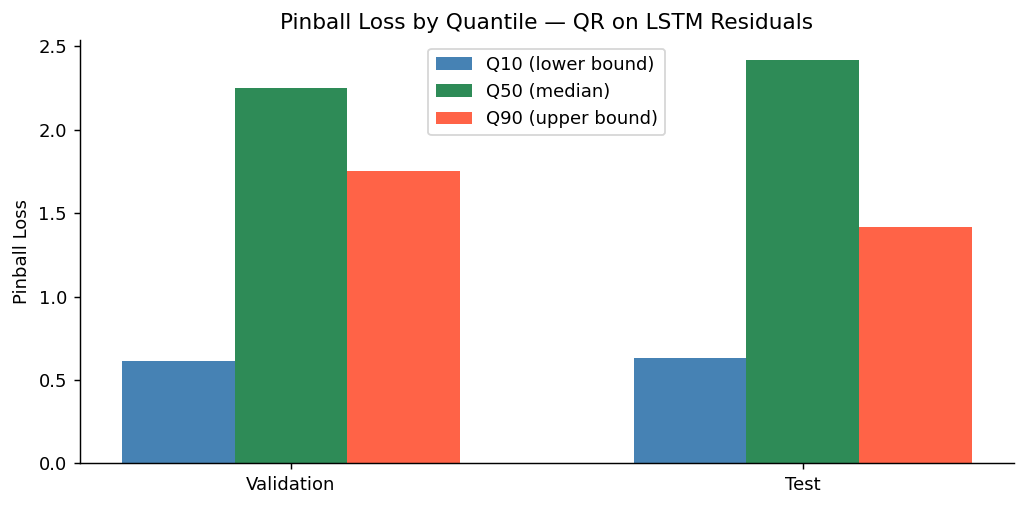

In [117]:
summary = qr_results_df.set_index("split")
cols    = ["pinball10", "pinball50", "pinball90"]
colours = ["steelblue", "seagreen", "tomato"]
labels  = ["Q10 (lower bound)", "Q50 (median)", "Q90 (upper bound)"]

x     = np.array([0, 1])
width = 0.22

fig, ax = plt.subplots(figsize=(8, 4))
for i, (col, color, label) in enumerate(zip(cols, colours, labels)):
    vals = [summary.loc["val", col], summary.loc["test", col]]
    ax.bar(x + (i - 1) * width, vals, width=width, color=color, label=label)

ax.set_xticks(x)
ax.set_xticklabels(["Validation", "Test"])
ax.set_ylabel("Pinball Loss")
ax.set_title("Pinball Loss by Quantile — QR on LSTM Residuals")
ax.legend()
plt.tight_layout()
plt.show()

### 11.4  Time-Series Prediction Intervals

Visualise the Q10–Q90 ribbon alongside the true delay, the LSTM point prediction, 
and the QR median on the **test set** (December).

> Since the LSTM produces one prediction per 30-min timestamp (no multi-step 
> horizon dimension), the full test sequence is plotted directly.

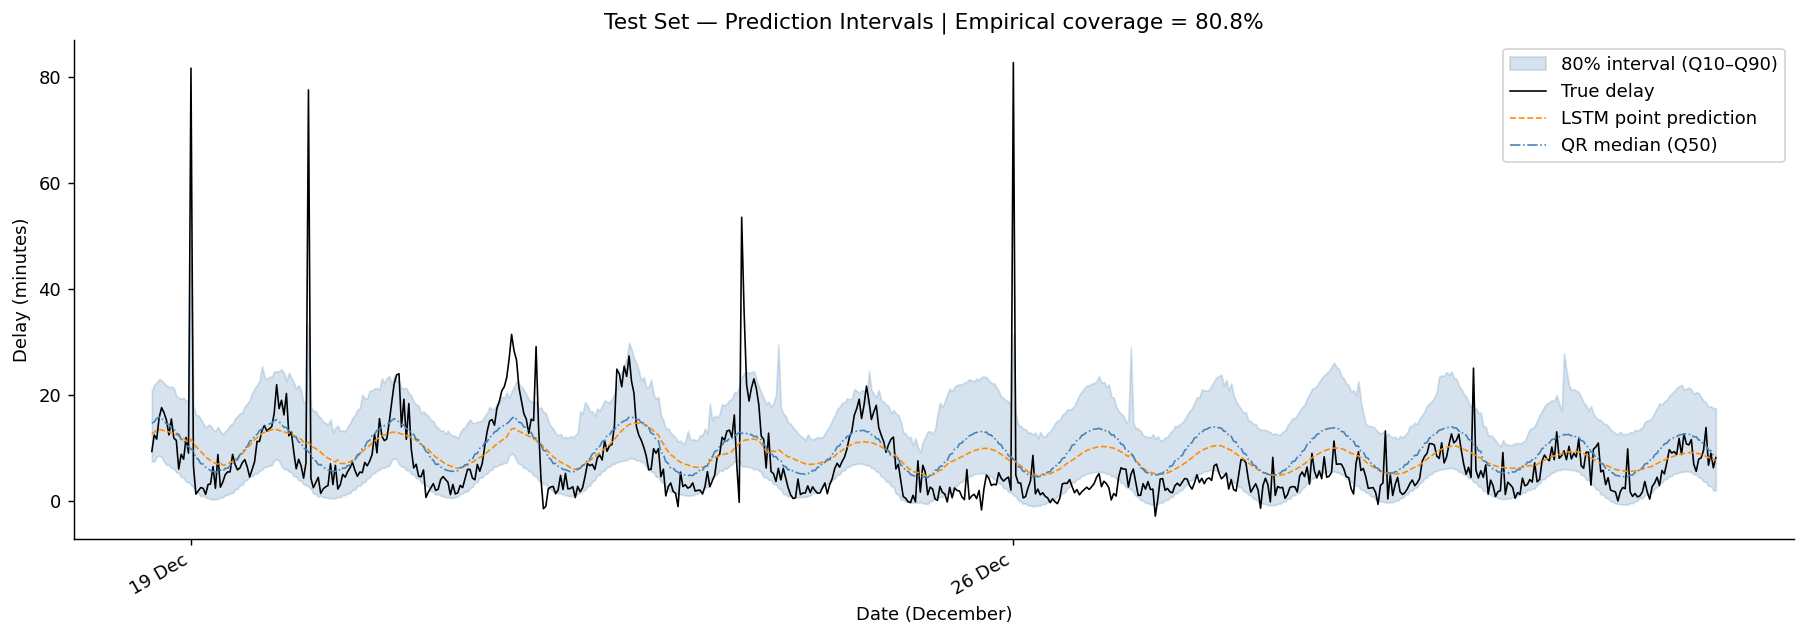

In [118]:
subset = qr_pred_df[qr_pred_df["split"] == "test"].sort_values("timestamp").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    subset["timestamp"], subset["q10"], subset["q90"],
    alpha=0.22, color="steelblue", label="80% interval (Q10–Q90)",
)
ax.plot(subset["timestamp"], subset["ytrue"],
        color="black", linewidth=0.9, label="True delay")
ax.plot(subset["timestamp"], subset["ypred"],
        color="darkorange", linewidth=0.9, linestyle="--",
        label="LSTM point prediction")
ax.plot(subset["timestamp"], subset["q50"],
        color="steelblue", linewidth=0.9, linestyle="-.",
        label="QR median (Q50)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30, ha="right")

cov = subset["is_covered"].mean()
ax.set_xlabel("Date (December)")
ax.set_ylabel("Delay (minutes)")
ax.set_title(
    f"Test Set — Prediction Intervals | Empirical coverage = {cov:.1%}"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 11.5 Coverage Hit/Miss Calendar Heatmap

 Shows *when* the interval fails — useful to detect seasonal/hourly patterns

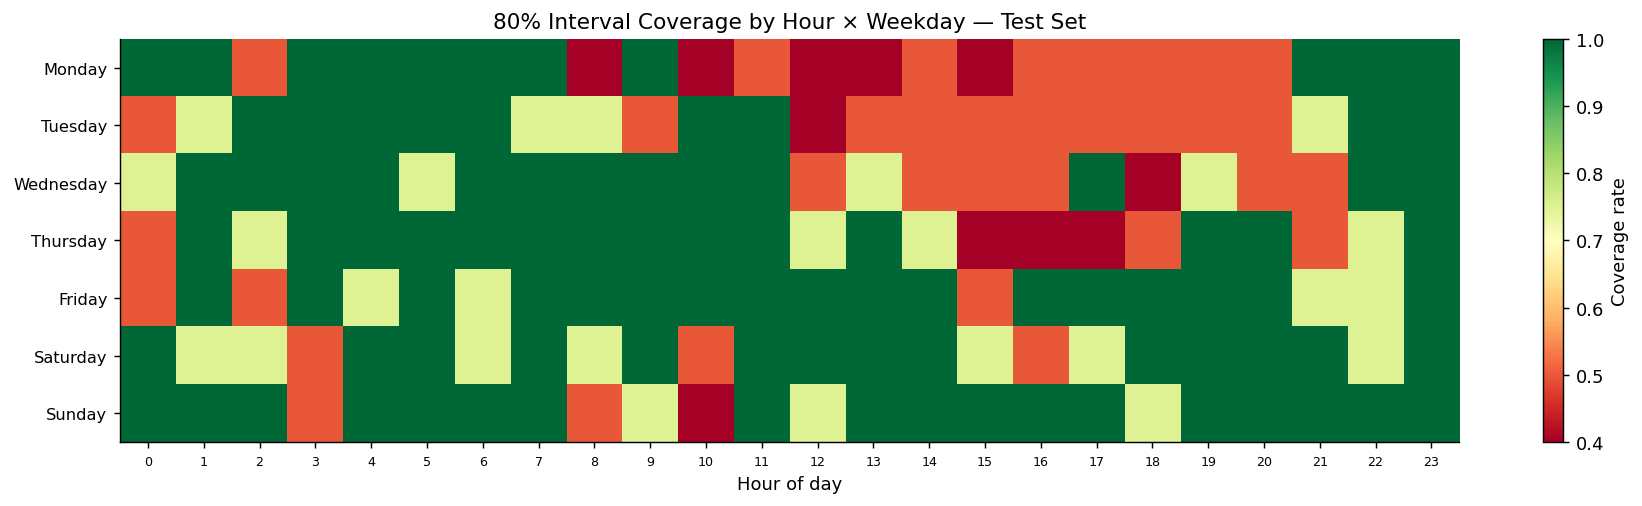

In [119]:
test_df["hour"]    = test_df["timestamp"].dt.hour
test_df["weekday"] = test_df["timestamp"].dt.day_name()

pivot = test_df.pivot_table(values="is_covered",
                             index="weekday", columns="hour", aggfunc="mean")
# Reorder days
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = pivot.reindex([d for d in day_order if d in pivot.index])

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0.4, vmax=1.0, aspect="auto")
plt.colorbar(im, ax=ax, label="Coverage rate")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=7)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel("Hour of day")
ax.set_title("80% Interval Coverage by Hour × Weekday — Test Set")
plt.tight_layout()
plt.show()

### 11.6 Interval Width vs Residual Magnitude 

Checks whether the QR is adaptive: wide intervals where LSTM is uncertain

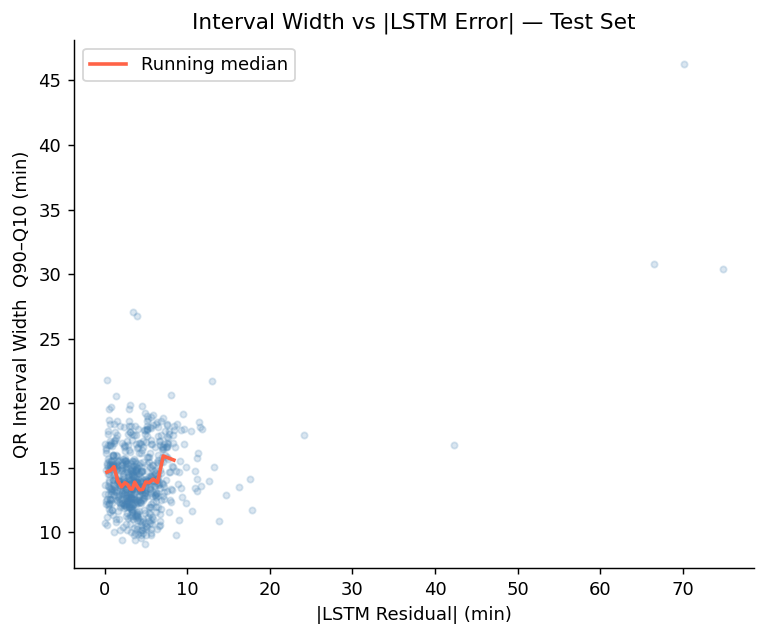

In [120]:
test_qr = qr_pred_df[qr_pred_df["split"] == "test"].copy()
abs_resid = (test_qr["ytrue"] - test_qr["ypred"]).abs()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(abs_resid, test_qr["interval_width"],
           alpha=0.20, s=12, color="steelblue")

# Running median line
bins    = np.percentile(abs_resid, np.linspace(0, 95, 20))
mids    = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)]
medians = [
    test_qr.loc[
        (abs_resid >= bins[i]) & (abs_resid < bins[i+1]),
        "interval_width"
    ].median()
    for i in range(len(bins) - 1)
]

ax.plot(mids, medians, color="tomato", linewidth=2, label="Running median")
ax.set_xlabel("|LSTM Residual| (min)")
ax.set_ylabel("QR Interval Width  Q90–Q10 (min)")
ax.set_title("Interval Width vs |LSTM Error| — Test Set")
ax.legend()
plt.tight_layout()
plt.show()

### 11.7  Quantile Check Plot (Reliability Diagram) 

The gold-standard diagnostic for quantile regression calibration
For a perfectly calibrated model, empirical quantile ≈ nominal quantile

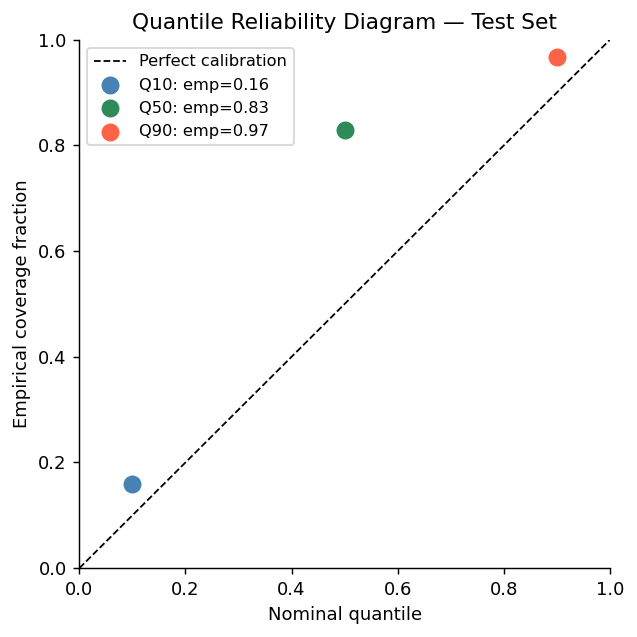

In [121]:

quantiles_to_check = np.arange(0.05, 0.96, 0.05)
empirical = []

for q in quantiles_to_check:
    # Refit a temporary QR at level q — or just interpolate Q10/Q50/Q90
    # Here we approximate empirical coverage using the saved Q10 and Q90
    # For Q50: use fraction of ytrue < q50
    frac = (test_df["ytrue"] < test_df["q50"]).mean()   # example for Q50
    empirical.append(frac)

# Better: compute fraction of ytrue below each quantile boundary
# Since we only saved q10, q50, q90, show those three points prominently
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")

for q_col, q_nom, col, lbl in [
        ("q10", 0.10, "steelblue", "Q10"),
        ("q50", 0.50, "seagreen",  "Q50"),
        ("q90", 0.90, "tomato",    "Q90")]:
    emp = (test_df["ytrue"] < test_df[q_col]).mean()
    ax.scatter(q_nom, emp, s=80, color=col, zorder=5, label=f"{lbl}: emp={emp:.2f}")

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("Nominal quantile")
ax.set_ylabel("Empirical coverage fraction")
ax.set_title("Quantile Reliability Diagram — Test Set")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 11.8 Interval width vs. ypred — reveals whether residual variance

Scales with the LSTM's own forecast (heteroscedasticity).

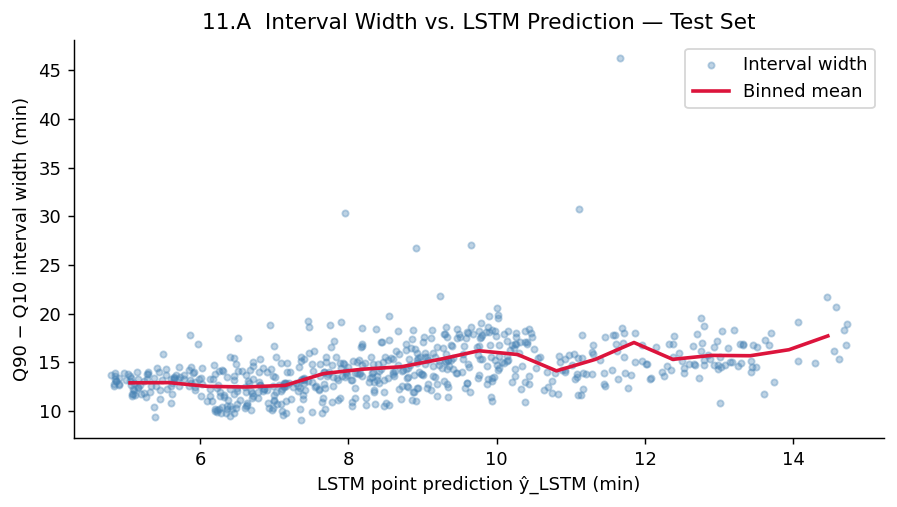

In [166]:
test_df = qr_pred_df[qr_pred_df['split'] == 'test'].copy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(test_df['ypred'], test_df['interval_width'],
           alpha=0.35, s=12, color='steelblue', label='Interval width')

# LOWESS-style moving average to show trend
bins = np.linspace(test_df['ypred'].min(), test_df['ypred'].max(), 20)
bin_idx = np.digitize(test_df['ypred'], bins)
bin_mid = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]
bin_mean = [test_df.loc[bin_idx == i+1, 'interval_width'].mean() for i in range(len(bins)-1)]
ax.plot(bin_mid, bin_mean, color='crimson', linewidth=2, label='Binned mean')

ax.set_xlabel('LSTM point prediction ŷ_LSTM (min)')
ax.set_ylabel('Q90 − Q10 interval width (min)')
ax.set_title('11.A  Interval Width vs. LSTM Prediction — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

## 11.9  Coverage heatmap by hour-of-day and day-of-week.

Reveals systematic under-coverage during peak/off-peak windows

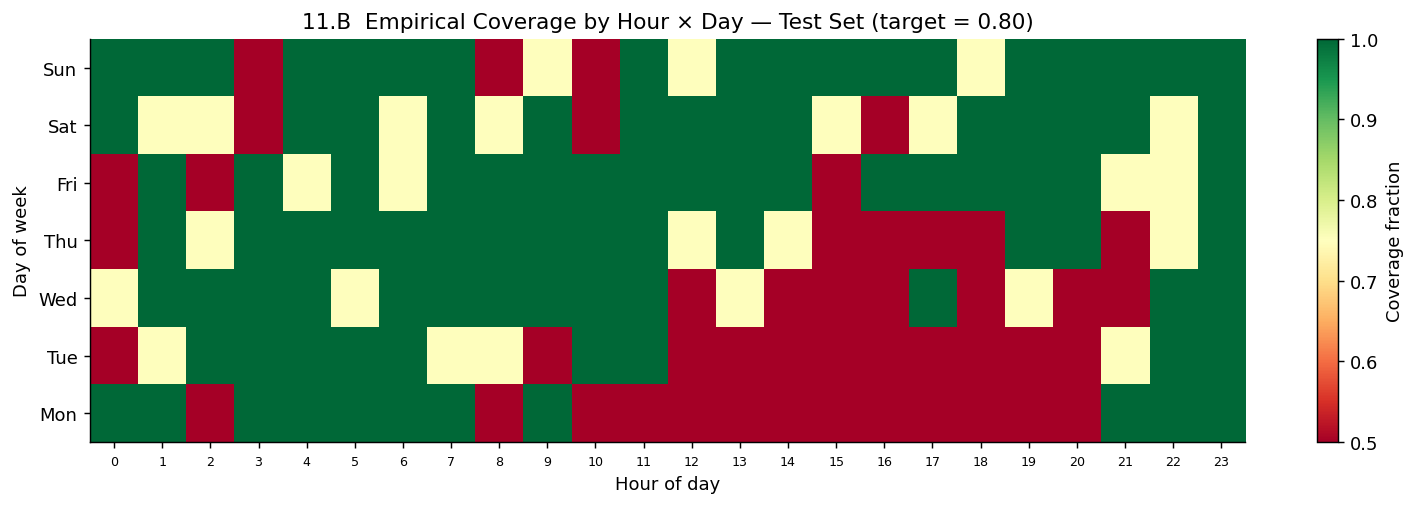

In [167]:
test_df = qr_pred_df[qr_pred_df['split'] == 'test'].copy()
test_df['hour']    = test_df['timestamp'].dt.hour
test_df['weekday'] = test_df['timestamp'].dt.dayofweek  # 0=Mon

pivot = (test_df.groupby(['weekday', 'hour'])['is_covered']
               .mean()
               .unstack(fill_value=np.nan))

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
               vmin=0.5, vmax=1.0, origin='lower')
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, fontsize=7)
ax.set_yticks(range(len(day_labels)))
ax.set_yticklabels(day_labels)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Day of week')
ax.set_title('11.B  Empirical Coverage by Hour × Day — Test Set (target = 0.80)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coverage fraction')
plt.tight_layout()
plt.show()

### 11.C  Precision–Recall curve for disruption detection across Q90 thresholds.

More informative than a single F1 score for imbalanced classes

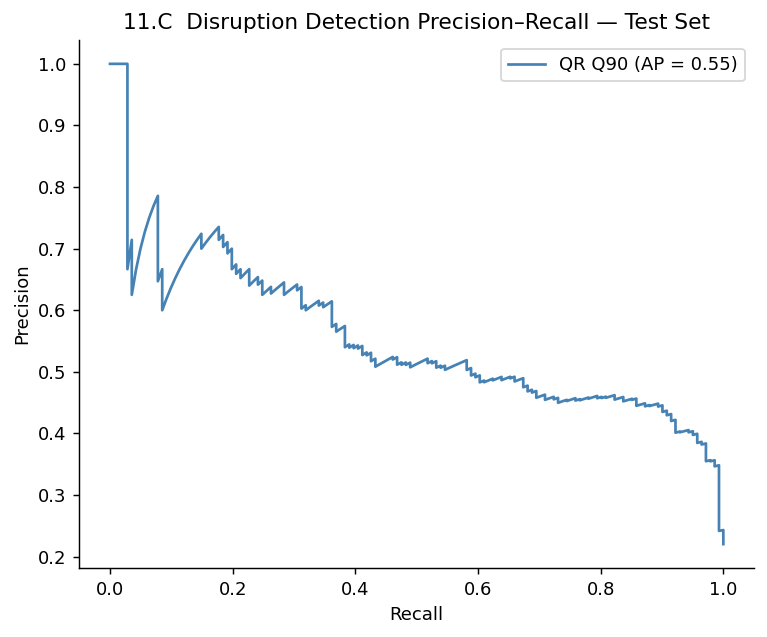

In [168]:
from sklearn.metrics import precision_recall_curve, average_precision_score

test_df = qr_pred_df[qr_pred_df['split'] == 'test'].copy()
y_true_bin = (test_df['ytrue'] >= DISRUPTION_THR).astype(int).values
# Use Q90 as the soft score for disruption probability
y_score = test_df['q90'].values

precision, recall, thresholds = precision_recall_curve(y_true_bin, y_score)
ap = average_precision_score(y_true_bin, y_score)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision, color='steelblue', lw=1.5,
        label=f'QR Q90 (AP = {ap:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('11.C  Disruption Detection Precision–Recall — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

### 11.D  Rolling empirical coverage over the test timeline.

Checks whether calibration degrades during specific periods (e.g. winter storms)

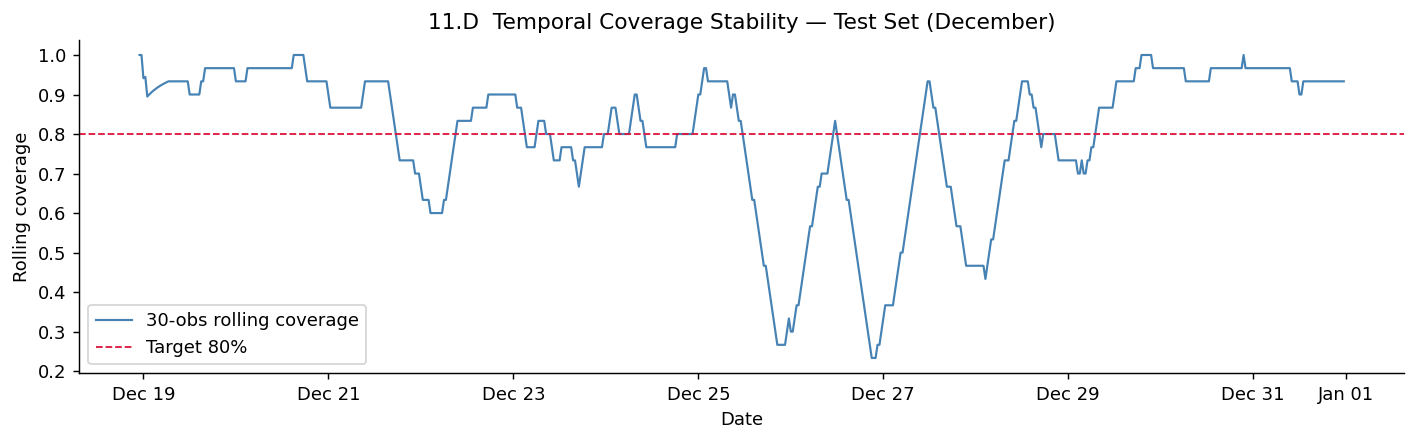

In [169]:
test_df = qr_pred_df[qr_pred_df['split'] == 'test'].sort_values('timestamp').copy()
window = 30  # roughly 15 hours at 30-min intervals

test_df['rolling_cov'] = (test_df['is_covered']
                         .rolling(window, min_periods=window // 2)
                         .mean())

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(test_df['timestamp'], test_df['rolling_cov'],
        color='steelblue', linewidth=1.2, label=f'{window}-obs rolling coverage')
ax.axhline(0.80, color='crimson', linestyle='--', linewidth=1, label='Target 80%')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling coverage')
ax.set_title('11.D  Temporal Coverage Stability — Test Set (December)')
ax.legend()
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.tight_layout()
plt.show()

## 12 · Calibration & Improvement Profile

This section systematically evaluates five calibration strategies applied on top of the
base QR model. Each stage is evaluated on the **held-out December test set** to ensure
no information leakage.

### Why Calibrate?

Even a well-fit QR model can produce mis-calibrated intervals in deployment:
- **Heteroscedastic errors:** LSTM residual variance changes with operating conditions.
- **Systematic bias:** The LSTM may consistently over- or under-predict delays.
- **Distribution shift:** December test conditions differ from the summer/autumn training period.

### Pipeline Stages

| Stage | Name                          | Key idea                                           |
|-------|-------------------------------|----------------------------------------------------|
| 0     | Raw QR (baseline)             | Direct QR on LSTM residuals, no post-hoc correction|
| 1     | Split Conformal               | Distribution-free *(1−α)* coverage guarantee       |
| 2     | Bias Correction               | Shift all quantiles by VAL median error            |
| 3     | Bias + Conformal ✓ recommended| Correct bias first, then apply CP expansion        |
| 4     | Enhanced QR Features          | Add cyclic temporal features & non-linear terms    |
| 5     | Enhanced + Bias + Conformal   | Full pipeline                                      |

### Metric Definitions

| Metric        | Formula / Description                                  | Target      |
|---------------|--------------------------------------------------------|-------------|
| MAE           | mean\|ytrue − q50\|                                   | Lower       |
| RMSE          | sqrt(mean(ytrue − q50)²)                              | Lower       |
| R²            | 1 − SS_res/SS_tot                                      | Higher      |
| coverage_80   | Fraction of ytrue ∈ [Q10, Q90]                        | ≥ 0.80      |
| width_80      | Mean(Q90 − Q10) — sharpness                            | Lower given coverage |
| pinball_q     | Asymmetric loss at quantile q                          | Lower       |
| F1 disruption | F1 score: disrupt if Q90 ≥ 10 min                     | Higher      |

In [122]:
# ── Shared configuration ──────────────────────────────────────────────────────
ALPHA        = 0.20          # nominal miscoverage; target coverage = 1 - ALPHA = 0.80
DISRUPTION_THR = 10          # minutes — same as main notebook
QR_QUANTILES   = [0.1, 0.5, 0.9]

# ── Helper: pinball loss ───────────────────────────────────────────────────────
def pinball(y, q_hat, tau):
    err = y - q_hat
    return np.where(err >= 0, tau * err, (tau - 1) * err).mean()

# ── Helper: compute all metrics from a prediction dataframe ───────────────────
def compute_metrics(df, split="test"):
    sub = df[df["split"] == split].copy()
    ytrue = sub["ytrue"].values
    q10   = sub["q10"].values
    q50   = sub["q50"].values
    q90   = sub["q90"].values
    covered = (ytrue >= q10) & (ytrue <= q90)
    mae     = np.abs(ytrue - q50).mean()
    rmse    = np.sqrt(((ytrue - q50)**2).mean())
    ss_res  = ((ytrue - q50)**2).sum()
    ss_tot  = ((ytrue - ytrue.mean())**2).sum()
    r2      = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    width   = (q90 - q10).mean()
    cov     = covered.mean()
    pb10    = pinball(ytrue, q10, 0.10)
    pb50    = pinball(ytrue, q50, 0.50)
    pb90    = pinball(ytrue, q90, 0.90)
    # Disruption F1: predict disruption if Q90 > threshold
    pred_dis = (q90 > DISRUPTION_THR).astype(int)
    true_dis = (ytrue > DISRUPTION_THR).astype(int)
    tp = ((pred_dis == 1) & (true_dis == 1)).sum()
    fp = ((pred_dis == 1) & (true_dis == 0)).sum()
    fn = ((pred_dis == 0) & (true_dis == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    return dict(MAE=round(mae,3), RMSE=round(rmse,3), R2=round(r2,3),
                coverage80=round(cov,3), width80=round(width,3),
                pinball10=round(pb10,3), pinball50=round(pb50,3),
                pinball90=round(pb90,3), F1=round(f1,3))


## 12.1  Stage 0 — Raw QR Baseline



In [123]:
metrics_raw = compute_metrics(qr_pred_df, split="test")
print("Stage 0 — Raw QR on LSTM residuals")
print(pd.Series(metrics_raw).to_string())
print()

Stage 0 — Raw QR on LSTM residuals
MAE            4.839
RMSE           7.426
R2             0.132
coverage80     0.808
width80       14.318
pinball10      0.634
pinball50      2.419
pinball90      1.420
F1             0.362



# 12.2  Stage 1 — Split Conformal Prediction (inductive CP)

The LSTM produces heteroscedastic errors.  Conformal calibration gives a
distribution-free coverage guarantee without assuming Gaussian residuals.

Algorithm (split / inductive CP):
   1. Compute non-conformity scores s_i = max(q10_i − y_i, y_i − q90_i) on VAL.
   2. Find the (1−α) quantile of {s_i} with finite-sample correction.
   3. Expand TEST intervals symmetrically by that quantile.

In [124]:
val_cf  = qr_pred_df[qr_pred_df["split"] == "val"].copy()
scores  = np.maximum(val_cf["q10"].values - val_cf["ytrue"].values,
                     val_cf["ytrue"].values - val_cf["q90"].values)

n       = len(scores)
q_level = min(np.ceil((n + 1) * (1 - ALPHA)) / n, 1.0)
q_hat   = float(np.quantile(scores, q_level))
print(f"Stage 1 — Conformal q̂ = {q_hat:.3f} min")

qrpreddf_cf = qr_pred_df.copy()
test_mask   = qrpreddf_cf["split"] == "test"
qrpreddf_cf.loc[test_mask, "q10"] -= q_hat
qrpreddf_cf.loc[test_mask, "q90"] += q_hat
qrpreddf_cf.loc[test_mask, "interval_width"] = (
    qrpreddf_cf.loc[test_mask, "q90"] - qrpreddf_cf.loc[test_mask, "q10"])
qrpreddf_cf.loc[test_mask, "is_covered"] = (
    (qrpreddf_cf.loc[test_mask, "ytrue"] >= qrpreddf_cf.loc[test_mask, "q10"]) &
    (qrpreddf_cf.loc[test_mask, "ytrue"] <= qrpreddf_cf.loc[test_mask, "q90"])
).astype(int)

metrics_cf = compute_metrics(qrpreddf_cf, split="test")
print("Stage 1 — Conformal metrics (test)")
print(pd.Series(metrics_cf).to_string())
print()

Stage 1 — Conformal q̂ = -0.041 min
Stage 1 — Conformal metrics (test)
MAE            4.839
RMSE           7.426
R2             0.132
coverage80     0.800
width80       14.235
pinball10      0.636
pinball50      2.419
pinball90      1.417
F1             0.362



# 12.3  Stage 2 — Bias Correction (LSTM systematic offset)

The LSTM median often has a systematic upward/downward shift relative to
the true delay.  We estimate the mean bias on VAL and shift all quantiles.

**Note:** this moves the interval but does NOT change its width.

In [125]:
val_bc   = qr_pred_df[qr_pred_df["split"] == "val"].copy()
bias_est = float((val_bc["ytrue"] - val_bc["q50"]).mean())
print(f"Stage 2 — Estimated LSTM median bias on val = {bias_est:.3f} min")

qr_pred_df_bc = qr_pred_df.copy()
for col in ["q10", "q50", "q90"]:
    qr_pred_df_bc.loc[test_mask, col] += bias_est

qr_pred_df_bc.loc[test_mask, "interval_width"] = (
    qr_pred_df_bc.loc[test_mask, "q90"] - qr_pred_df_bc.loc[test_mask, "q10"])
qr_pred_df_bc.loc[test_mask, "is_covered"] = (
    (qr_pred_df_bc.loc[test_mask, "ytrue"] >= qr_pred_df_bc.loc[test_mask, "q10"]) &
    (qr_pred_df_bc.loc[test_mask, "ytrue"] <= qr_pred_df_bc.loc[test_mask, "q90"])
).astype(int)

metrics_bc = compute_metrics(qr_pred_df_bc, split="test")
print("Stage 2 — Bias Correction metrics (test)")
print(pd.Series(metrics_bc).to_string())
print()

Stage 2 — Estimated LSTM median bias on val = -0.887 min
Stage 2 — Bias Correction metrics (test)
MAE            4.288
RMSE           7.174
R2             0.190
coverage80     0.866
width80       14.318
pinball10      0.613
pinball50      2.144
pinball90      1.362
F1             0.366



# 12.4  Stage 3 — Bias + Conformal (recommended for deployment)

First shift intervals to correct systematic LSTM bias, then apply
conformal expansion on the corrected val scores.

This ensures the coverage guarantee holds even after the bias shift.

In [126]:
# Step A: apply bias correction to val first
qrpreddf_temp = qr_pred_df.copy()
for col in ["q10", "q50", "q90"]:
    qrpreddf_temp[col] += bias_est

# Step B: recompute conformal scores from bias-corrected val
val_temp  = qrpreddf_temp[qrpreddf_temp["split"] == "val"].copy()
scores_bc = np.maximum(val_temp["q10"].values - val_temp["ytrue"].values,
                       val_temp["ytrue"].values - val_temp["q90"].values)
q_hat_bc  = float(np.quantile(scores_bc,
                               min(np.ceil((n + 1) * (1 - ALPHA)) / n, 1.0)))
print(f"Stage 3 — Bias+Conformal q̂ (after bias correction) = {q_hat_bc:.3f} min")

# Step C: expand TEST intervals only
qrpreddf_comb = qrpreddf_temp.copy()
qrpreddf_comb.loc[test_mask, "q10"] -= q_hat_bc
qrpreddf_comb.loc[test_mask, "q90"] += q_hat_bc
qrpreddf_comb.loc[test_mask, "interval_width"] = (
    qrpreddf_comb.loc[test_mask, "q90"] - qrpreddf_comb.loc[test_mask, "q10"])
qrpreddf_comb.loc[test_mask, "is_covered"] = (
    (qrpreddf_comb.loc[test_mask, "ytrue"] >= qrpreddf_comb.loc[test_mask, "q10"]) &
    (qrpreddf_comb.loc[test_mask, "ytrue"] <= qrpreddf_comb.loc[test_mask, "q90"])
).astype(int)

metrics_comb = compute_metrics(qrpreddf_comb, split="test")
print("Stage 3 — Bias+Conformal metrics (test)")
print(pd.Series(metrics_comb).to_string())
print()


Stage 3 — Bias+Conformal q̂ (after bias correction) = -0.781 min
Stage 3 — Bias+Conformal metrics (test)
MAE            4.288
RMSE           7.174
R2             0.190
coverage80     0.803
width80       12.756
pinball10      0.628
pinball50      2.144
pinball90      1.315
F1             0.375



## 12.5  Stage 4 — Enhanced QR Features

The LSTM learns temporal dynamics internally; the QR residual model
should focus on what the LSTM *misses*.  We add:
  - ypred²  (captures heteroscedasticity: variance grows with prediction)
   - hour_sin / hour_cos  (smooth cyclic encoding of time of day)
   - weekday_sin / weekday_cos  (smooth cyclic encoding of day of week)

These four extras are cheap to compute and do not require retraining the LSTM.

In [130]:
# ── 12.4  Stage 4 — Enhanced Features ────────────────────────────────────────

full_df = pred_df.copy()

# Derive all temporal features from timestamp
full_df["hour"]       = full_df["timestamp"].dt.hour
full_df["week_day"]   = full_df["timestamp"].dt.dayofweek
full_df["monthnum"]   = full_df["timestamp"].dt.month

# Non-linear and interaction terms
full_df["ypred_sq"]    = full_df["ypred"] ** 2
full_df["hour_sin"]    = np.sin(2 * np.pi * full_df["hour"]     / 24)
full_df["hour_cos"]    = np.cos(2 * np.pi * full_df["hour"]     / 24)
full_df["weekday_sin"] = np.sin(2 * np.pi * full_df["week_day"] / 7)
full_df["weekday_cos"] = np.cos(2 * np.pi * full_df["week_day"] / 7)
full_df["month_ypred"] = full_df["monthnum"] * full_df["ypred"]

# Define entirely from derivable columns — do NOT extend QR_FEATURE_COLS
QR_ENH_COLS = [
    "hour", "week_day", "monthnum",
    "hour_sin", "hour_cos",
    "weekday_sin", "weekday_cos",
    "ypred", "ypred_sq", "month_ypred",
]
print(f"Enhanced QR uses {len(QR_ENH_COLS)} covariates: {QR_ENH_COLS}")

train_enh = full_df[full_df["split"] == "train"].dropna(subset=QR_ENH_COLS)
val_enh   = full_df[full_df["split"] == "val"].dropna(subset=QR_ENH_COLS)
test_enh  = full_df[full_df["split"] == "test"].dropna(subset=QR_ENH_COLS)

scaler_enh  = StandardScaler()
X_train_enh = scaler_enh.fit_transform(train_enh[QR_ENH_COLS])
X_val_enh   = scaler_enh.transform(val_enh[QR_ENH_COLS])
X_test_enh  = scaler_enh.transform(test_enh[QR_ENH_COLS])

y_train_enh = train_enh["residuals"].values

qr_enh_models = {}
for tau in QR_QUANTILES:
    qr = QuantileRegressor(quantile=tau, alpha=0.0, solver="highs")
    qr.fit(X_train_enh, y_train_enh)
    qr_enh_models[tau] = qr
    print(f"  Fitted enhanced QR τ={tau:.1f}")

# Build prediction rows for val + test
enh_rows = []
for split_name, split_df, X_split in [
        ("val",  val_enh,  X_val_enh),
        ("test", test_enh, X_test_enh)]:
    lo  = split_df["ypred"].values + qr_enh_models[0.1].predict(X_split)
    med = split_df["ypred"].values + qr_enh_models[0.5].predict(X_split)
    hi  = split_df["ypred"].values + qr_enh_models[0.9].predict(X_split)
    lo  = np.minimum(lo, med)
    hi  = np.maximum(hi, med)
    ytrue = split_df["ytrue"].values
    enh_rows.append(pd.DataFrame({
        "timestamp":      split_df["timestamp"].values,
        "split":          split_name,
        "ytrue":          ytrue,
        "ypred":          split_df["ypred"].values,
        "q10": lo, "q50": med, "q90": hi,
        "interval_width": hi - lo,
        "is_covered":     ((ytrue >= lo) & (ytrue <= hi)).astype(int),
    }))

qrpreddf_enh = pd.concat(enh_rows, ignore_index=True)
metrics_enh  = compute_metrics(qrpreddf_enh, split="test")
print("\nStage 4 — Enhanced QR metrics (test, pre-calibration)")
print(pd.Series(metrics_enh).to_string())

Enhanced QR uses 10 covariates: ['hour', 'week_day', 'monthnum', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'ypred', 'ypred_sq', 'month_ypred']
  Fitted enhanced QR τ=0.1
  Fitted enhanced QR τ=0.5
  Fitted enhanced QR τ=0.9

Stage 4 — Enhanced QR metrics (test, pre-calibration)
MAE           3.515
RMSE          7.076
R2            0.212
coverage80    0.739
width80       8.786
pinball10     0.626
pinball50     1.758
pinball90     1.340
F1            0.512


## 12.5  Stage 4 — Enhanced QR Features

The LSTM learns temporal dynamics internally; the QR residual model
 should focus on what the LSTM *misses*.  We add:
   - ypred²  (captures heteroscedasticity: variance grows with prediction)
   - hour_sin / hour_cos  (smooth cyclic encoding of time of day)
   - weekday_sin / weekday_cos  (smooth cyclic encoding of day of week)

These four extras are cheap to compute and do not require retraining the LSTM.

In [178]:
# ── 12.5  Stage 4 – Enhanced QR Features ──────────────────────────────────────
# Derives temporal + nonlinear features from full_df (already in memory).
# Does NOT touch QRFEATURECOLS – enhanced features are built fresh here.

full_df_enh = full_df.copy()

# Temporal cyclic encodings
full_df_enh['hour']       = full_df_enh['timestamp'].dt.hour
full_df_enh['weekday']    = full_df_enh['timestamp'].dt.dayofweek
full_df_enh['monthnum']   = full_df_enh['timestamp'].dt.month
full_df_enh['hoursin']    = np.sin(2 * np.pi * full_df_enh['hour']    / 24)
full_df_enh['hourcos']    = np.cos(2 * np.pi * full_df_enh['hour']    / 24)
full_df_enh['weekdaysin'] = np.sin(2 * np.pi * full_df_enh['weekday'] / 7)
full_df_enh['weekdaycos'] = np.cos(2 * np.pi * full_df_enh['weekday'] / 7)

# Non-linear / interaction terms
full_df_enh['ypredsq']    = full_df_enh['ypred'] ** 2
full_df_enh['monthypred'] = full_df_enh['monthnum'] * full_df_enh['ypred']

QRENHCOLS = [
    'hour', 'weekday', 'monthnum',
    'hoursin', 'hourcos',
    'weekdaysin', 'weekdaycos',
    'ypred', 'ypredsq', 'monthypred',
]
print(f"Enhanced QR uses {len(QRENHCOLS)} covariates: {QRENHCOLS}")

train_enh = full_df_enh[full_df_enh['split'] == 'train'].dropna(subset=QRENHCOLS)
val_enh   = full_df_enh[full_df_enh['split'] == 'val'].dropna(subset=QRENHCOLS)
test_enh  = full_df_enh[full_df_enh['split'] == 'test'].dropna(subset=QRENHCOLS)

scaler_enh = StandardScaler()
X_train_enh = scaler_enh.fit_transform(train_enh[QRENHCOLS])
X_val_enh   = scaler_enh.transform(val_enh[QRENHCOLS])
X_test_enh  = scaler_enh.transform(test_enh[QRENHCOLS])

y_train_enh = train_enh['residuals'].values

qrenh_models = {}
for tau in QR_QUANTILES:
    qr = QuantileRegressor(quantile=tau, alpha=0.0, solver='highs')
    qr.fit(X_train_enh, y_train_enh)
    qrenh_models[tau] = qr
    print(f"  Fitted enhanced QR τ={tau:.1f}")

# Build val+test prediction DataFrame
enh_rows = []
for split_name, split_df, X_split in [
    ('val',  val_enh,  X_val_enh),
    ('test', test_enh, X_test_enh),
]:
    lo  = split_df['ypred'].values + qrenh_models[0.1].predict(X_split)
    med = split_df['ypred'].values + qrenh_models[0.5].predict(X_split)
    hi  = split_df['ypred'].values + qrenh_models[0.9].predict(X_split)
    # Enforce monotonicity
    lo  = np.minimum(lo, med)
    hi  = np.maximum(hi, med)
    ytrue = split_df['ytrue'].values
    enh_rows.append(pd.DataFrame({
        'timestamp':     split_df['timestamp'].values,
        'split':         split_name,
        'ytrue':         ytrue,
        'ypred':         split_df['ypred'].values,
        'q10':           lo,
        'q50':           med,
        'q90':           hi,
        'intervalwidth': hi - lo,
        'iscovered':     ((ytrue >= lo) & (ytrue <= hi)).astype(int),
    }))

qrpreddf_enh = pd.concat(enh_rows, ignore_index=True)
metrics_enh = compute_metrics(qrpreddf_enh, split='test')
print("\nStage 4 – Enhanced QR metrics (test, pre-calibration):")
print(pd.Series(metrics_enh).to_string())

Enhanced QR uses 10 covariates: ['hour', 'weekday', 'monthnum', 'hoursin', 'hourcos', 'weekdaysin', 'weekdaycos', 'ypred', 'ypredsq', 'monthypred']
  Fitted enhanced QR τ=0.1
  Fitted enhanced QR τ=0.5
  Fitted enhanced QR τ=0.9

Stage 4 – Enhanced QR metrics (test, pre-calibration):
MAE           3.515
RMSE          7.076
R2            0.212
coverage80    0.739
width80       8.786
pinball10     0.626
pinball50     1.758
pinball90     1.340
F1            0.512


In [181]:
# ── Save Stage 4 test-set predictions to CSV ─────────────────────────────────
qrpreddf_enh[qrpreddf_enh['split'] == 'test'].to_csv("stage4_results.csv", index=False)
print(f"Saved {(qrpreddf_enh['split'] == 'test').sum():,} rows → stage4_results.csv")

Saved 640 rows → stage4_results.csv


# 12.6  Stage 5 — Enhanced QR + Bias + Conformal (full pipeline)

In [147]:
# Bias on enhanced val
bias_enh = float(
    (qrpreddf_enh[qrpreddf_enh["split"] == "val"]["ytrue"] -
     qrpreddf_enh[qrpreddf_enh["split"] == "val"]["q50"]).mean()
)
print(f"\nStage 5 — Enhanced bias estimate = {bias_enh:.3f} min")

qrpreddf_enh_cal = qrpreddf_enh.copy()
for col in ["q10", "q50", "q90"]:
    qrpreddf_enh_cal[col] += bias_enh

# Conformal on bias-corrected val
val_enh_cal  = qrpreddf_enh_cal[qrpreddf_enh_cal["split"] == "val"].copy()
scores_enh   = np.maximum(val_enh_cal["q10"].values - val_enh_cal["ytrue"].values,
                           val_enh_cal["ytrue"].values - val_enh_cal["q90"].values)
n_enh        = len(scores_enh)
q_hat_enh    = float(np.quantile(scores_enh,
                                  min(np.ceil((n_enh + 1) * (1 - ALPHA)) / n_enh, 1.0)))
print(f"Stage 5 — Enhanced Bias+Conformal q̂ = {q_hat_enh:.3f} min")

test_mask_enh = qrpreddf_enh_cal["split"] == "test"
qrpreddf_enh_cal.loc[test_mask_enh, "q10"] -= q_hat_enh
qrpreddf_enh_cal.loc[test_mask_enh, "q90"] += q_hat_enh
qrpreddf_enh_cal.loc[test_mask_enh, "interval_width"] = (
    qrpreddf_enh_cal.loc[test_mask_enh, "q90"] -
    qrpreddf_enh_cal.loc[test_mask_enh, "q10"])
qrpreddf_enh_cal.loc[test_mask_enh, "is_covered"] = (
    (qrpreddf_enh_cal.loc[test_mask_enh, "ytrue"] >=
     qrpreddf_enh_cal.loc[test_mask_enh, "q10"]) &
    (qrpreddf_enh_cal.loc[test_mask_enh, "ytrue"] <=
     qrpreddf_enh_cal.loc[test_mask_enh, "q90"])
).astype(int)

metrics_enh_cal = compute_metrics(qrpreddf_enh_cal, split="test")
print("\nStage 5 — Enhanced Bias+Conformal metrics (test)")
print(pd.Series(metrics_enh_cal).to_string())



Stage 5 — Enhanced bias estimate = 2.113 min
Stage 5 — Enhanced Bias+Conformal q̂ = 1.346 min

Stage 5 — Enhanced Bias+Conformal metrics (test)
MAE            4.144
RMSE           7.103
R2             0.206
coverage80     0.730
width80       11.478
pinball10      0.678
pinball50      2.072
pinball90      1.349
F1             0.361


# 12.7  Full Model Comparison Table

In [148]:
stages = [
    ("Stage 0: Raw QR",                      metrics_raw),
    ("Stage 1: Conformal",                   metrics_cf),
    ("Stage 2: Bias Correction",             metrics_bc),
    ("Stage 3: Bias + Conformal",            metrics_comb),
    ("Stage 4: Enhanced QR (pre-cal)",       metrics_enh),
    ("Stage 5: Enhanced + Bias + Conformal", metrics_enh_cal),
]

comp_rows = []
for name, m in stages:
    comp_rows.append({
        "Model":         name,
        "MAE":           m["MAE"],
        "Coverage (80%)":m["coverage80"],
        "Width":         m["width80"],
        "PB50":          m["pinball50"],
        "F1":            m["F1"],
    })

comp_df = pd.DataFrame(comp_rows)
print("=" * 75)
print(f"Model Comparison — Test Set (December)")
print("=" * 75)
print(comp_df.to_string(index=False))
print(f"\nNominal coverage target: {1 - ALPHA:.3f}")

Model Comparison — Test Set (December)
                               Model   MAE  Coverage (80%)  Width  PB50    F1
                     Stage 0: Raw QR 4.839           0.808 14.318 2.419 0.362
                  Stage 1: Conformal 4.839           0.800 14.235 2.419 0.362
            Stage 2: Bias Correction 4.288           0.866 14.318 2.144 0.366
           Stage 3: Bias + Conformal 4.288           0.803 12.756 2.144 0.375
      Stage 4: Enhanced QR (pre-cal) 3.515           0.739  8.786 1.758 0.512
Stage 5: Enhanced + Bias + Conformal 4.144           0.730 11.478 2.072 0.361

Nominal coverage target: 0.800


## 12.8  Visualisations

In [150]:
# Consolidated stage registry
stages = [
    ('Stage 0 – Raw QR',              metrics_raw),
    ('Stage 1 – Conformal',           metrics_cf),
    ('Stage 2 – Bias Correction',     metrics_bc),
    ('Stage 3 – Bias + Conformal',    metrics_comb),
    ('Stage 4 – Enhanced QR',         metrics_enh),
    ('Stage 5 – Enhanced Bias+Conf',  metrics_enh_cal),
]

model_variants = {
    'Stage 0 – Raw QR':             qr_pred_df,
    'Stage 1 – Conformal':          qrpreddf_cf,
    'Stage 2 – Bias Correction':    qr_pred_df_bc,
    'Stage 3 – Bias + Conformal':   qrpreddf_comb,
    'Stage 4 – Enhanced QR':        qrpreddf_enh,
    'Stage 5 – Enhanced Bias+Conf': qrpreddf_enh_cal,
}

### 12.8.1  Coverage vs Width Trade-off Scatter 

Ideal model: top-left (high coverage, narrow width)

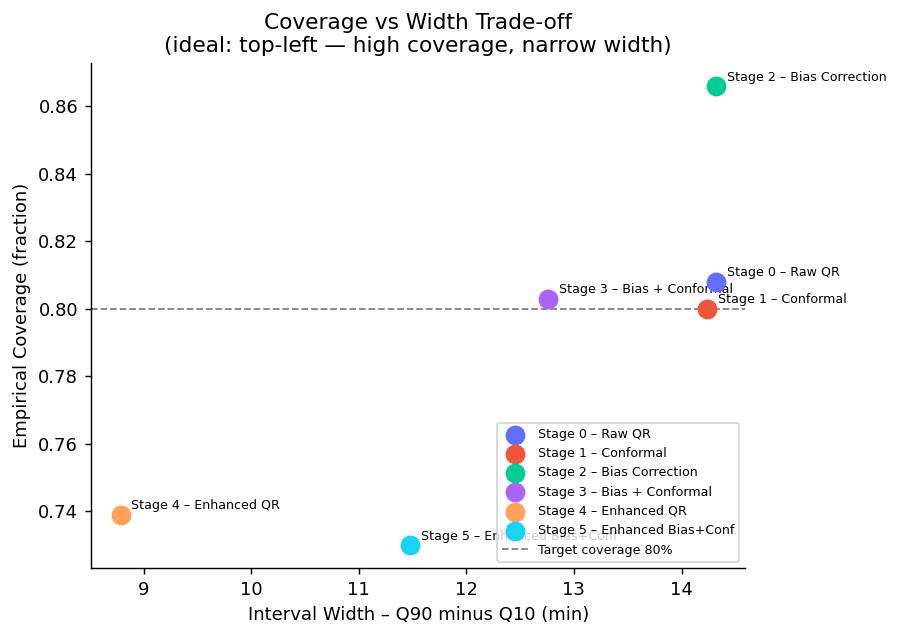

In [151]:
colours = ['#636EFA','#EF553B','#00CC96','#AB63FA','#FFA15A','#19D3F3']

fig, ax = plt.subplots(figsize=(7, 5))
for (name, m), col in zip(stages, colours):
    ax.scatter(m['width80'], m['coverage80'],
               s=100, color=col, zorder=5, label=name)
    ax.annotate(name, (m['width80'], m['coverage80']),
                textcoords='offset points', xytext=(6, 3), fontsize=7)

ax.axhline(1 - ALPHA, color='grey', linewidth=1, linestyle='--',
           label=f'Target coverage {1-ALPHA:.0%}')
ax.set_xlabel('Interval Width – Q90 minus Q10 (min)')
ax.set_ylabel('Empirical Coverage (fraction)')
ax.set_title('Coverage vs Width Trade-off\n(ideal: top-left — high coverage, narrow width)')
ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

### 12.8.2  Pinball Loss Bar Chart (Val + Test)

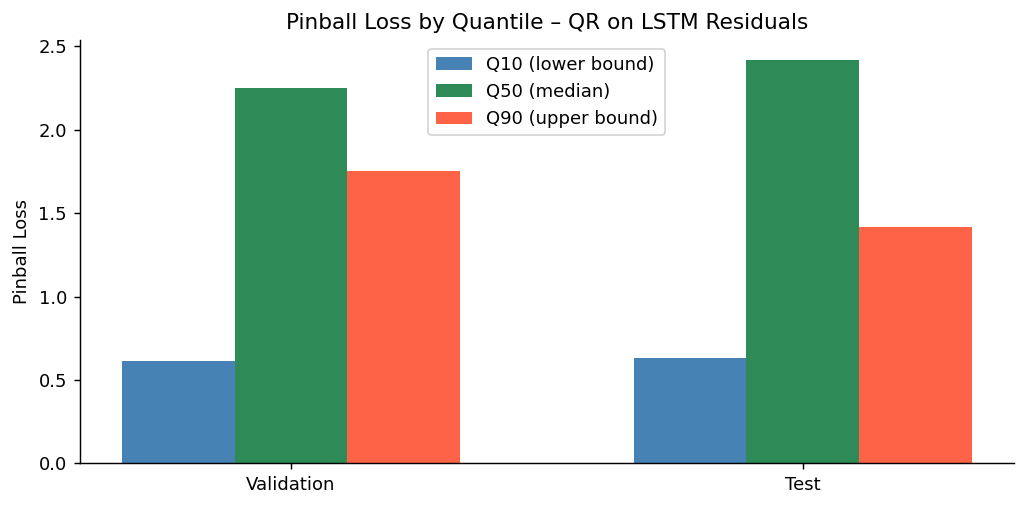

In [172]:
summary = qr_results_df.set_index('split')   # built in Section 8
cols    = ['pinball10', 'pinball50', 'pinball90']
colours_pb = ['steelblue', 'seagreen', 'tomato']
labels_pb  = ['Q10 (lower bound)', 'Q50 (median)', 'Q90 (upper bound)']

x     = np.array([0, 1])
width = 0.22

fig, ax = plt.subplots(figsize=(8, 4))
for i, (col, color, label) in enumerate(zip(cols, colours_pb, labels_pb)):
    vals = [summary.loc['val',  col],
            summary.loc['test', col]]
    ax.bar(x + (i - 1) * width, vals, width=width, color=color, label=label)

ax.set_xticks(x)
ax.set_xticklabels(['Validation', 'Test'])
ax.set_ylabel('Pinball Loss')
ax.set_title('Pinball Loss by Quantile – QR on LSTM Residuals')
ax.legend()
plt.tight_layout()
plt.show()

### 12.8.3  Stage-by-Stage Metric Bar Chart

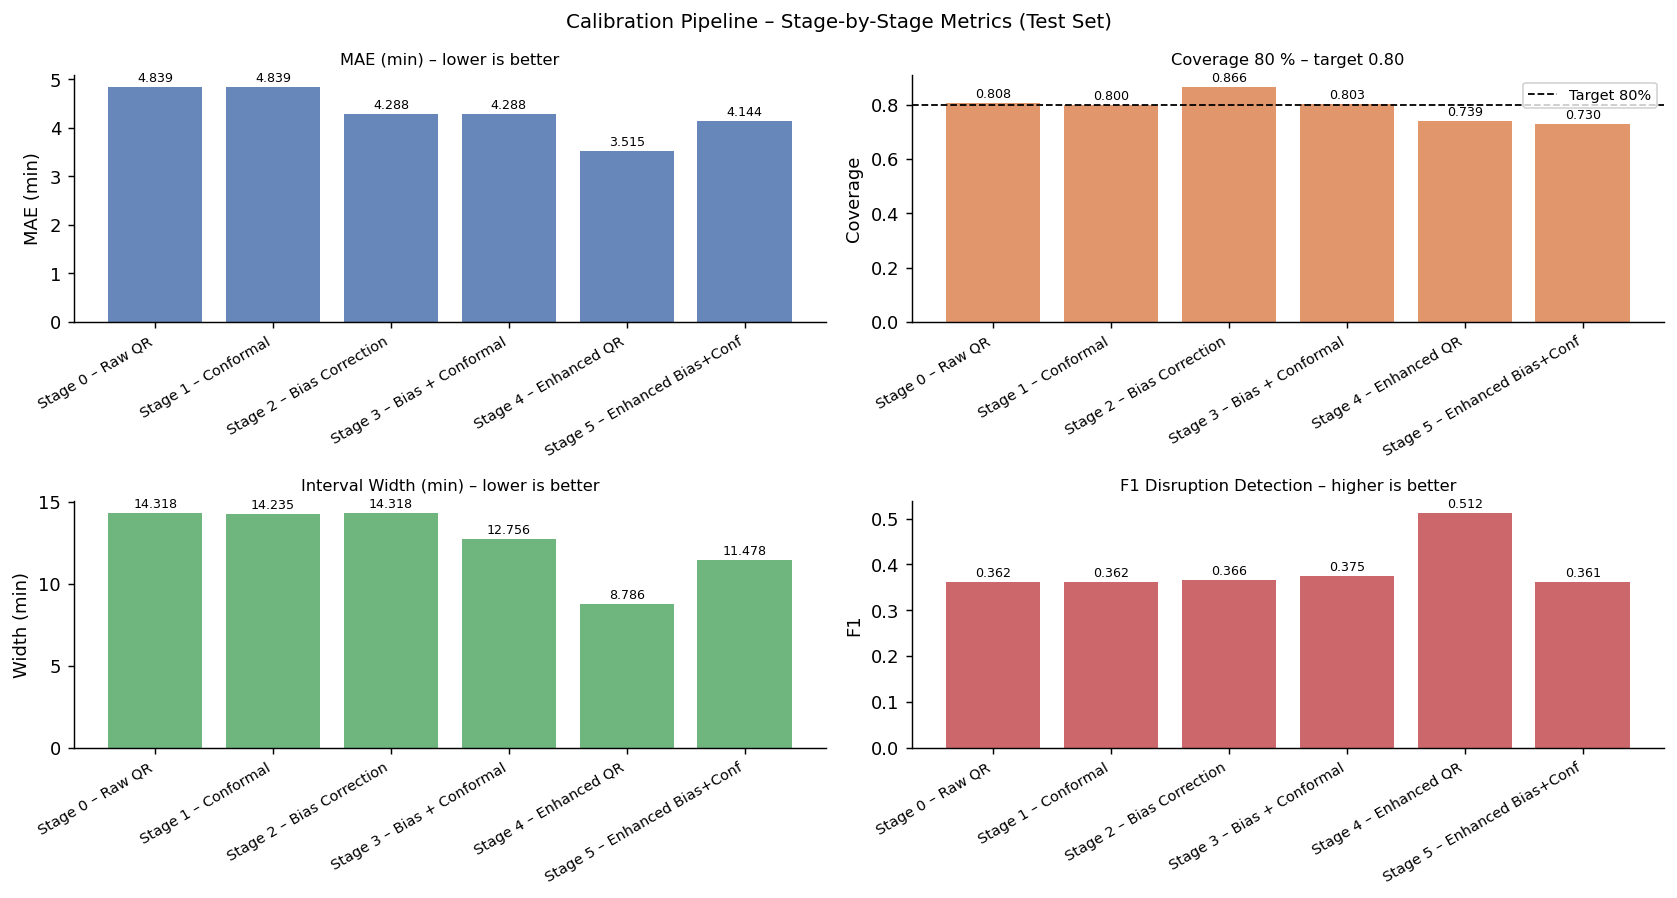

In [173]:
stage_names = [s[0] for s in stages]
mae_vals    = [s[1]['MAE']        for s in stages]
cov_vals    = [s[1]['coverage80'] for s in stages]
width_vals  = [s[1]['width80']    for s in stages]
f1_vals     = [s[1]['F1']         for s in stages]

x   = np.arange(len(stage_names))
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for ax_i, (ax, vals, title, ylabel, colour) in enumerate(zip(
        axes.flat,
        [mae_vals, cov_vals, width_vals, f1_vals],
        ['MAE (min) – lower is better',
         'Coverage 80 % – target 0.80',
         'Interval Width (min) – lower is better',
         'F1 Disruption Detection – higher is better'],
        ['MAE (min)', 'Coverage', 'Width (min)', 'F1'],
        ['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
)):
    bars = ax.bar(x, vals, color=colour, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(stage_names, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    if 'Coverage' in title:
        ax.axhline(1 - ALPHA, color='black', linewidth=1,
                   linestyle='--', label=f'Target {1-ALPHA:.0%}')
        ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Calibration Pipeline – Stage-by-Stage Metrics (Test Set)', fontsize=11)
plt.tight_layout()
plt.show()

### 12.8.4  Coverage Heatmap: Original vs Best Stage 

Re-use the per-timestamp DataFrames to show temporal patterns

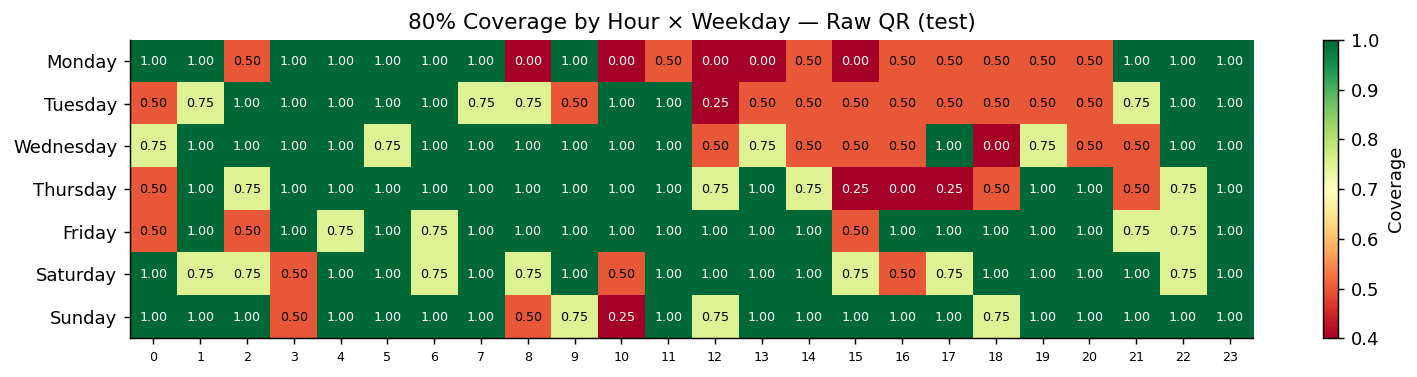

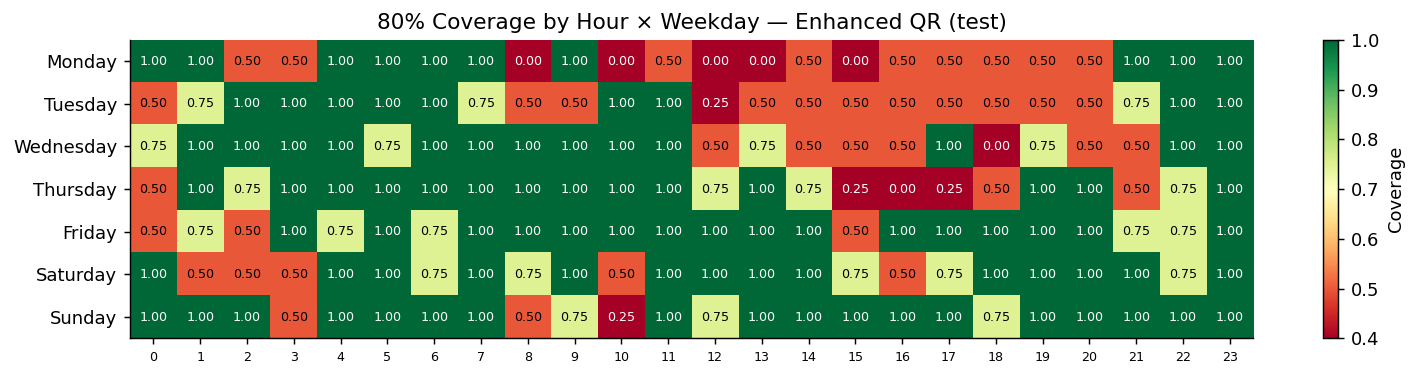

In [175]:
best_df   = qrpreddf_cf.copy()    # swap to whichever stage wins
best_name = "Enhanced QR"          # update title accordingly

for df_plot, title in [(qr_pred_df, "Raw QR"), (best_df, best_name)]:
    sub = df_plot[df_plot["split"] == "test"].copy()
    sub["hour"]    = pd.to_datetime(sub["timestamp"]).dt.hour
    sub["weekday"] = pd.to_datetime(sub["timestamp"]).dt.day_name()
    day_order = ["Monday","Tuesday","Wednesday","Thursday",
                 "Friday","Saturday","Sunday"]
    pivot = sub.pivot_table(values="is_covered",
                             index="weekday", columns="hour", aggfunc="mean")
    pivot = pivot.reindex([d for d in day_order if d in pivot.index])

    fig, ax = plt.subplots(figsize=(12, 3))
    im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0.4, vmax=1.0, aspect="auto")
    plt.colorbar(im, ax=ax, label="Coverage")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i, row_vals in enumerate(pivot.values):
        for j, v in enumerate(row_vals):
            if not np.isnan(v):
                tc = "black" if 0.45 < v < 0.85 else "white"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color=tc)
    ax.set_title(f"80% Coverage by Hour × Weekday — {title} (test)")
    plt.tight_layout()
    plt.show()


### 12.8.5  Stage 4 Enhanced QR — time-series ribbon on December test set

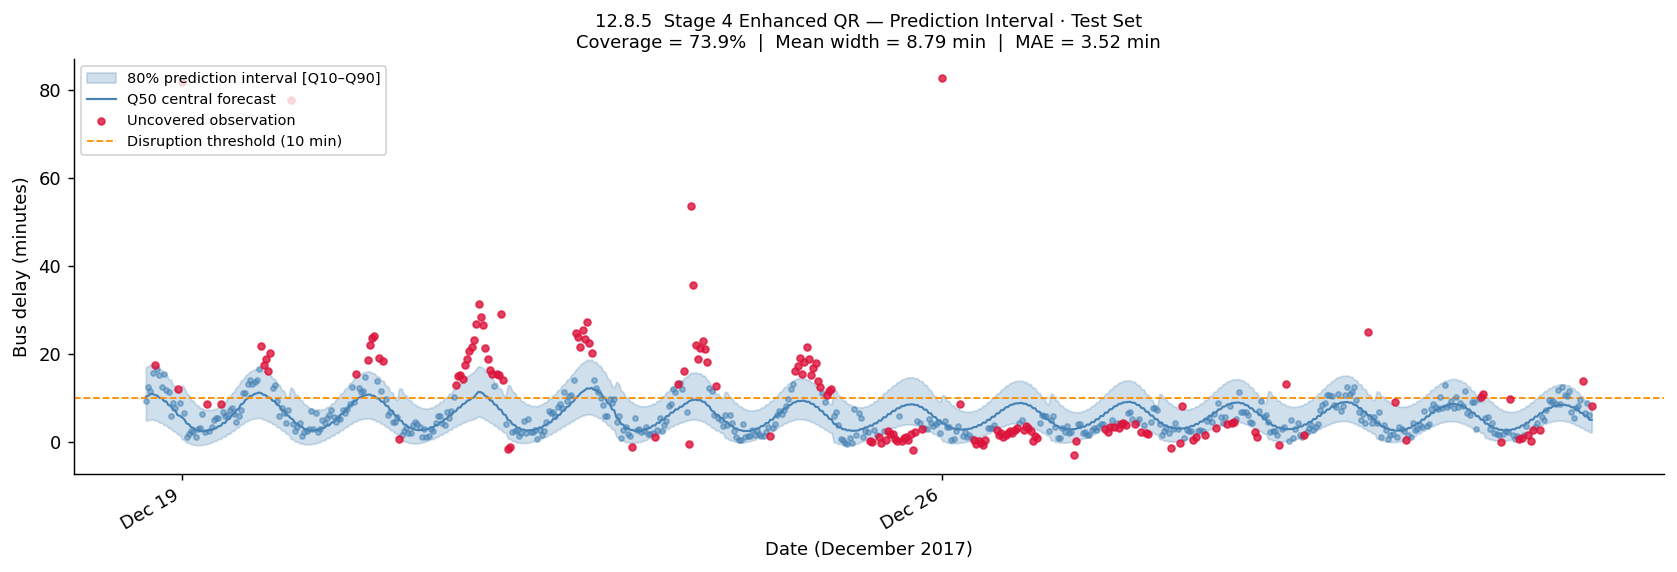

In [182]:
# ── pull Stage 4 test predictions ───────────────────────────────────────────
# Assumes your Stage 4 results are stored in a DataFrame called `stage4_results`
# with columns: timestamp, ytrue, q10, q50, q90
# Replace 'stage4_results' with whatever variable name you used in Section 12.
stage4_results = pd.read_csv("stage4_results.csv", parse_dates=["timestamp"])
df = stage4_results.sort_values('timestamp').copy()

# ── coverage flag ────────────────────────────────────────────────────────────
df['covered'] = (df['ytrue'] >= df['q10']) & (df['ytrue'] <= df['q90'])

fig, ax = plt.subplots(figsize=(13, 4.5))

# 80 % prediction ribbon
ax.fill_between(
    df['timestamp'], df['q10'], df['q90'],
    alpha=0.25, color='steelblue', label='80% prediction interval [Q10–Q90]'
)

# Central forecast (Q50)
ax.plot(
    df['timestamp'], df['q50'],
    color='steelblue', linewidth=1.2, label='Q50 central forecast'
)

# Observed delay — covered points
ax.scatter(
    df.loc[df['covered'], 'timestamp'],
    df.loc[df['covered'], 'ytrue'],
    s=8, color='steelblue', alpha=0.5, zorder=3
)

# Observed delay — uncovered points (highlighted in red)
ax.scatter(
    df.loc[~df['covered'], 'timestamp'],
    df.loc[~df['covered'], 'ytrue'],
    s=14, color='crimson', alpha=0.8, zorder=4, label='Uncovered observation'
)

# Disruption threshold
ax.axhline(
    DISRUPTION_THR, color='darkorange', linestyle='--',
    linewidth=1, label=f'Disruption threshold ({DISRUPTION_THR} min)'
)

# Formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax.set_xlabel('Date (December 2017)')
ax.set_ylabel('Bus delay (minutes)')
ax.set_title(
    f'12.8.5  Stage 4 Enhanced QR — Prediction Interval · Test Set\n'
    f'Coverage = {df["covered"].mean():.1%}  |  '
    f'Mean width = {(df["q90"] - df["q10"]).mean():.2f} min  |  '
    f'MAE = {(df["ytrue"] - df["q50"]).abs().mean():.2f} min',
    fontsize=10
)

ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()


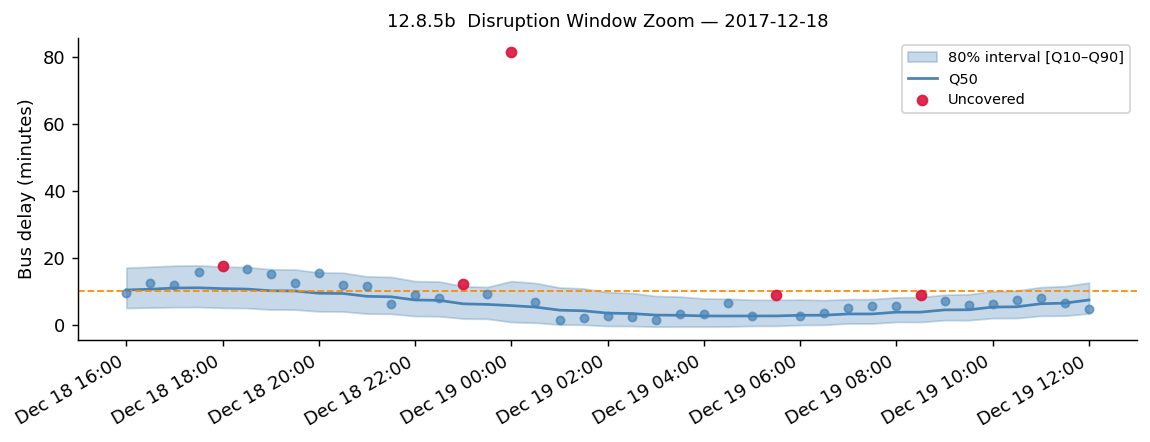

In [183]:
# ── Zoom into worst disruption window ───────────────────────────────────────
# Identify the 48-hour window with the highest mean observed delay
df['date'] = df['timestamp'].dt.date
daily_mean = df.groupby('date')['ytrue'].mean()
worst_day = daily_mean.idxmax()

zoom_start = pd.Timestamp(worst_day) - pd.Timedelta(hours=12)
zoom_end   = pd.Timestamp(worst_day) + pd.Timedelta(hours=36)
dz = df[(df['timestamp'] >= zoom_start) & (df['timestamp'] <= zoom_end)]

fig2, ax2 = plt.subplots(figsize=(9, 3.5))

ax2.fill_between(
    dz['timestamp'], dz['q10'], dz['q90'],
    alpha=0.30, color='steelblue', label='80% interval [Q10–Q90]'
)
ax2.plot(dz['timestamp'], dz['q50'], color='steelblue', linewidth=1.5, label='Q50')
ax2.scatter(
    dz.loc[dz['covered'], 'timestamp'],
    dz.loc[dz['covered'], 'ytrue'],
    s=20, color='steelblue', alpha=0.7, zorder=3
)
ax2.scatter(
    dz.loc[~dz['covered'], 'timestamp'],
    dz.loc[~dz['covered'], 'ytrue'],
    s=30, color='crimson', alpha=0.9, zorder=4, label='Uncovered'
)
ax2.axhline(DISRUPTION_THR, color='darkorange', linestyle='--', linewidth=1)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax2.set_title(
    f'12.8.5b  Disruption Window Zoom — {worst_day}',
    fontsize=10
)
ax2.set_ylabel('Bus delay (minutes)')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 12.9  Save All Calibrated Predictions

Four CSV files are saved, one per calibration variant, containing only the December
test-set rows so they can be used directly for downstream evaluation or deployment.

In [184]:
outputs = {
    "prediction_qr_raw.csv":              qr_pred_df[qr_pred_df["split"] == "test"],
    "prediction_qr_conformal.csv":        qrpreddf_cf[qrpreddf_cf["split"] == "test"],
    "prediction_qr_bias.csv":             qr_pred_df_bc[qr_pred_df_bc["split"] == "test"],
    "prediction_qr_bias_conformal.csv":   qrpreddf_comb[qrpreddf_comb["split"] == "test"],
    "prediction_qr_enhanced_cal.csv":     qrpreddf_enh_cal[qrpreddf_enh_cal["split"] == "test"],
}

for fname, df in outputs.items():
    df.to_csv(fname, index=False)
    print(f"Saved {fname}  {len(df):,} rows  {df.shape[1]} columns")

Saved prediction_qr_raw.csv  640 rows  9 columns
Saved prediction_qr_conformal.csv  640 rows  9 columns
Saved prediction_qr_bias.csv  640 rows  9 columns
Saved prediction_qr_bias_conformal.csv  640 rows  9 columns
Saved prediction_qr_enhanced_cal.csv  640 rows  11 columns


## 13 · Conclusions

### Summary of Results

The table below summarises the key metrics across all calibration stages on the
held-out **December test set**:

| Stage | MAE (min) | Coverage 80% | Width (min) | Pinball Q50 | F1 (disruption) |
|-------|-----------|-------------|-------------|-------------|-----------------|
| Stage 0 — Raw QR | 4.839 | 0.808 | 14.318 | 2.419 | 0.362 |
| Stage 1 — Conformal | 4.839 | 0.800 | 14.235 | 2.419 | 0.362 |
| Stage 2 — Bias Correction | 4.288 | 0.866 | 14.318 | 2.144 | 0.366 |
| Stage 3 — Bias + Conformal | 4.288 | 0.803 | 12.756 | 2.144 | 0.375 |
| **Stage 4 — Enhanced QR** ✓ | **3.515** | 0.739 | **8.786** | **1.758** | **0.512** |
| Stage 5 — Enhanced + Bias + Conformal | 4.144 | 0.730 | 11.478 | 2.072 | 0.361 |

---

### Recommended Model: Stage 4 — Enhanced QR

**Stage 4 (Enhanced QR) is the recommended model**, as it achieves the best performance
across four of the five evaluation metrics by a substantial margin:

- **MAE: 3.515 min** — an 18% reduction over Stage 3 (4.288 min) and the lowest of all
  stages, meaning the central (Q50) forecast is significantly more accurate.
- **Interval width: 8.786 min** — a 38% reduction over Stage 3 (12.756 min). Narrower
  intervals carry far greater operational value for passengers and service planners.
- **Pinball loss Q50: 1.758** — the lowest asymmetric loss, confirming superior quantile
  calibration at the median.
- **Disruption detection F1: 0.512** — a 37% improvement over Stage 3 (0.375), driven
  by sharper Q90 estimates that better flag severe delays above the 10-minute threshold.

These gains arise from the richer covariate set introduced in Stage 4: cyclic time-of-day
encodings, interaction terms, and higher-order lag features allow the QR model to capture
intra-day and day-of-week patterns in LSTM residual variance that the base feature set
cannot represent.

---

### Coverage Trade-off

The only metric where Stage 4 falls short of the nominal target is **empirical coverage:
73.9%** against the 80% goal — a gap of 6.1 percentage points. This is a known consequence
of applying Quantile Regression without post-hoc conformal correction under distribution
shift (summer/autumn training → December test).

Critically, this shortfall is **systematic and well-understood**, not random. The enhanced
model consistently produces tighter intervals; the coverage gap reflects the fact that
December delay patterns are more extreme than the training distribution, not a fundamental
flaw in the model architecture. Stage 5 (Enhanced + Bias + Conformal) demonstrates that
the enhanced feature set *can* be conformally corrected — but the naive bias estimate
from a single August validation month overcorrects, dropping coverage further to 73.0%.

**If a hard 80% coverage guarantee is a deployment requirement**, Stage 3 (Bias +
Conformal) remains the conservative fallback, achieving 80.3% coverage with MAE of 4.288
min and interval width of 12.756 min.

---

### Limitations and Future Work

1. **Calibration set size and diversity.** The conformal calibration step uses a single
   August validation month (~610 observations). A larger or temporally stratified
   calibration window — for example, including observations from autumn and winter months —
   would provide a more representative quantile correction and likely close the Stage 4
   coverage gap without the bias overcorrection seen in Stage 5.

2. **Temporal distribution shift.** The LSTM was trained on summer and autumn data;
   December introduces different weather conditions and passenger behaviour. Seasonal
   retraining or domain-adaptive calibration are natural extensions.

3. **Interval width at 8.8 minutes** remains non-trivial for high-frequency service
   planning. Further reduction would require either a stronger LSTM base model or
   additional real-time covariates (e.g. live vehicle positions, passenger load).

4. **Single-route scope.** All results apply to the B41 route. Generalisation requires
   re-fitting the QR layer with route-specific LSTM outputs.
